In [1]:
%pip install "numpy>=2.0,<2.3" --force-reinstall

  Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import sys
from pathlib import Path

import coffea.util
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

sidm_path = str(Path.cwd()).split('/sidm')[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)

from sidm.tools import utilities

utilities.set_plot_style()
%matplotlib inline


In [2]:
cwd = Path.cwd()
if (cwd / 'Mother_Tracking_LJ_Kinematics_BKG').exists():
    study_dir = cwd
elif (cwd / 'studies' / 'Mother_Tracking').exists():
    study_dir = cwd / 'studies' / 'Mother_Tracking'
else:
    raise RuntimeError(f'Cannot locate studies/Mother_Tracking from {cwd}')

repo_dir = study_dir.parents[1]
mother_dir = study_dir / 'Mother_Tracking_LJ_Kinematics_BKG'
kin_dir = study_dir / 'Mother_Tracking_LJ_Kinematics_BKG'

channels = {
    '1 Mu-LJ': 'data_control_region_1muLj_cosmic_veto',
    '1 EGM-LJ': 'data_control_region_1egmLj_cosmic_veto',
    '1 Mu-LJ and 1 EGM-LJ': 'data_control_region_1muLj_1egmLj_cosmic_veto',
    '2 Mu-LJ': 'data_control_region_2muLj_cosmic_veto',
}

QCD = [
    'QCD_Pt15To20', 'QCD_Pt20To30', 'QCD_Pt30To50', 'QCD_Pt50To80',
    'QCD_Pt80To120', 'QCD_Pt120To170', 'QCD_Pt170To300', 'QCD_Pt300To470',
    'QCD_Pt470To600', 'QCD_Pt600To800', 'QCD_Pt800To1000', 'QCD_Pt1000',
]
DY = ['DYJetsToMuMu_M10to50', 'DYJetsToMuMu_M50']
TT = ['TTJets']
Diboson = ['WW', 'WZ', 'ZZ']

background_groups = {
    'QCD': QCD,
    'DY': DY,
    'TT': TT,
    'Diboson': Diboson,
}

all_background_samples = sorted({sample for samples in background_groups.values() for sample in samples})
mother_hist_name = 'fs_gen_mother_id'

print('study_dir =', study_dir)
print('mother_dir =', mother_dir)
print('kin_dir =', kin_dir)

background_samples = all_background_samples
background_label = 'Background'


study_dir = /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Mother_Tracking
mother_dir = /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Mother_Tracking/Mother_Tracking_LJ_Kinematics_BKG
kin_dir = /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Mother_Tracking/Mother_Tracking_LJ_Kinematics_BKG


In [3]:
def load_sample_output(path, sample):
    output = coffea.util.load(path)
    if 'out' in output:
        return output['out'][sample]
    return output[sample]


def load_outputs(directory, samples):
    out = {}
    missing = []
    for sample in samples:
        path = Path(directory) / f'{sample}.coffea'
        if not path.exists():
            missing.append(sample)
            continue
        out[sample] = load_sample_output(path, sample)
    if missing:
        print(f'Missing {len(missing)} samples in {directory}: {missing}')
    return out


mother_out = load_outputs(mother_dir, all_background_samples)
kin_out = load_outputs(kin_dir, all_background_samples)
print(f'Loaded {len(mother_out)} MotherTracking samples')
print(f'Loaded {len(kin_out)} LJKinematics samples')


Loaded 18 MotherTracking samples
Loaded 18 LJKinematics samples


In [4]:
MOTHER_CATEGORY_IDS = {
    'W': (24,),
    'Z': (23,),
    'D': (411, 421, 423, 431),
    'B': (511, 521, 531, 541),
    'quark/gluon': (1, 2, 3, 4, 5, 6, 9, 21),
    'pion': (111, 211),
    'eta/omega': (221, 223),
    'J/psi': (443,),
    'electron': (11,),
    'muon': (13,),
}
CATEGORY_ORDER = list(MOTHER_CATEGORY_IDS) + ['other']
CATEGORY_COLORS = {
    'W': '#1f77b4',
    'Z': '#ff7f0e',
    'D': '#2ca02c',
    'B': '#d62728',
    'quark/gluon': '#9467bd',
    'pion': '#8c564b',
    'eta/omega': '#e377c2',
    'J/psi': '#7f7f7f',
    'electron': '#bcbd22',
    'muon': '#17becf',
    'other': '#c7c7c7',
}
CHANNEL_COLORS = {
    '1 Mu-LJ': 'r',
    '1 EGM-LJ': 'g',
    '1 Mu-LJ and 1 EGM-LJ': 'b',
    '2 Mu-LJ': 'darkorange',
}


def hist_values_1d(hist_obj):
    values = np.asarray(hist_obj.values(), dtype=float)
    variances = hist_obj.variances()
    variances = np.zeros_like(values) if variances is None else np.asarray(variances, dtype=float)
    centers = np.asarray(hist_obj.axes[0].centers, dtype=float)
    return centers, values, variances


def group_hist(out, samples, channel, hist_name):
    total = None
    used = []
    skipped = []
    for sample in samples:
        if sample not in out:
            skipped.append((sample, 'not loaded'))
            continue
        hists = out[sample]['hists']
        if hist_name not in hists:
            skipped.append((sample, f'missing {hist_name}'))
            continue
        try:
            h = hists[hist_name][{'channel': channel}]
        except Exception as exc:
            skipped.append((sample, f'cannot slice {channel}: {exc}'))
            continue
        total = h.copy() if total is None else total + h
        used.append(sample)
    if skipped:
        print(f'{hist_name} / {channel}: skipped {len(skipped)} samples')
        for sample, reason in skipped[:5]:
            print(f'  {sample}: {reason}')
        if len(skipped) > 5:
            print('  ...')
    return total, used


def total_yield(hist_obj):
    return float(np.asarray(hist_obj.values(), dtype=float).sum())


def channel_yield_table(out, samples, hist_name=mother_hist_name):
    rows = []
    for channel_label, channel in channels.items():
        h, used = group_hist(out, samples, channel, hist_name)
        rows.append({
            'channel': channel_label,
            'yield': np.nan if h is None else total_yield(h),
            'n_samples': len(used),
        })
    table = pd.DataFrame(rows).set_index('channel')
    ref = table.loc['1 Mu-LJ', 'yield']
    table['ratio_to_1MuLJ'] = table['yield'] / ref if ref > 0 else np.nan
    return table


def plot_channel_yield_ratios(table, title):
    ax = table['ratio_to_1MuLJ'].plot(kind='bar', figsize=(18, 8), color=[CHANNEL_COLORS[idx] for idx in table.index])
    ax.axhline(1.0, color='black', linestyle='--', linewidth=2)
    ax.set_ylabel('Yield ratio to 1 Mu-LJ')
    ax.set_title(title)
    plt.tight_layout()
    return ax


def mother_category_yields(hist_obj):
    centers, values, _ = hist_values_1d(hist_obj)
    pdgids = np.floor(centers).astype(int)
    yields = {}
    used_mask = np.zeros_like(pdgids, dtype=bool)
    for category, ids in MOTHER_CATEGORY_IDS.items():
        mask = np.isin(pdgids, ids)
        yields[category] = values[mask].sum()
        used_mask |= mask
    yields['other'] = values[~used_mask].sum()
    return pd.Series(yields)[CATEGORY_ORDER]


def mother_composition_table(out, samples):
    rows = {}
    for channel_label, channel in channels.items():
        h, used = group_hist(out, samples, channel, mother_hist_name)
        if h is None:
            rows[channel_label] = pd.Series(np.nan, index=CATEGORY_ORDER)
            continue
        yields = mother_category_yields(h)
        total = yields.sum()
        rows[channel_label] = 100.0 * yields / total if total > 0 else yields * np.nan
    return pd.DataFrame(rows).T[CATEGORY_ORDER]


def plot_mother_composition(table, title):
    colors = [CATEGORY_COLORS[category] for category in table.columns]
    ax = table.plot(kind='bar', stacked=True, figsize=(30, 15), width=0.8, color=colors)
    ax.set_ylabel('Mother composition [%]')
    ax.set_ylim(0, 100)
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Mother', fontsize=25)
    plt.tight_layout()
    return ax




def hist_edges_1d(hist_obj):
    values = np.asarray(hist_obj.values(), dtype=float)
    variances = hist_obj.variances()
    variances = np.zeros_like(values) if variances is None else np.asarray(variances, dtype=float)
    edges = np.asarray(hist_obj.axes[0].edges, dtype=float)
    return edges, values, variances


def _rebin_1d(edges, values, variances, factor=1):
    factor = int(factor)
    if factor <= 1:
        return edges, values, variances
    n_bins = len(values)
    grouped_edges = [edges[0]]
    grouped_values = []
    grouped_variances = []
    for start in range(0, n_bins, factor):
        stop = min(start + factor, n_bins)
        grouped_values.append(values[start:stop].sum())
        grouped_variances.append(variances[start:stop].sum())
        grouped_edges.append(edges[stop])
    return np.asarray(grouped_edges), np.asarray(grouped_values), np.asarray(grouped_variances)


def normalized_shape(hist_obj, rebin=1):
    edges, values, variances = hist_edges_1d(hist_obj)
    edges, values, variances = _rebin_1d(edges, values, variances, factor=rebin)
    total = values.sum()
    if total <= 0:
        return edges, values * np.nan, variances * np.nan
    return edges, values / total, np.sqrt(np.maximum(variances, 0.0)) / total


def projected_shape_2d(hist_obj, axis_name, rebin=1):
    axis_names = [axis.name for axis in hist_obj.axes]
    if axis_name not in axis_names:
        raise KeyError(f'{axis_name} not found in axes {axis_names}')
    project_axis = axis_names.index(axis_name)
    values = np.asarray(hist_obj.values(), dtype=float)
    variances = hist_obj.variances()
    variances = np.zeros_like(values) if variances is None else np.asarray(variances, dtype=float)
    sum_axes = tuple(i for i in range(values.ndim) if i != project_axis)
    projected_values = values.sum(axis=sum_axes)
    projected_variances = variances.sum(axis=sum_axes)
    edges = np.asarray(hist_obj.axes[project_axis].edges, dtype=float)
    edges, projected_values, projected_variances = _rebin_1d(
        edges,
        projected_values,
        projected_variances,
        factor=rebin,
    )
    total = projected_values.sum()
    if total <= 0:
        return edges, projected_values * np.nan, projected_variances * np.nan
    return edges, projected_values / total, np.sqrt(np.maximum(projected_variances, 0.0)) / total


def _bin_centers(edges):
    return 0.5 * (edges[:-1] + edges[1:])


def add_shape_error_points(ax, edges, values, errors, color):
    valid = np.isfinite(values) & np.isfinite(errors) & (errors > 0)
    if not np.any(valid):
        return

    centers = _bin_centers(edges)
    ax.errorbar(
        centers[valid],
        values[valid],
        yerr=errors[valid],
        fmt='o',
        markersize=5,
        markerfacecolor=color,
        markeredgecolor=color,
        ecolor=color,
        elinewidth=1.5,
        capsize=2,
        linestyle='none',
        zorder=5,
    )


def _finish_shape_axis(ax, edges_by_channel, xlabel, ylabel, title, ylim=None, xlim=None, logy=False):
    finite_edges = [edges for edges in edges_by_channel if len(edges) > 1 and np.all(np.isfinite(edges))]
    if xlim is not None:
        ax.set_xlim(*xlim)
    elif finite_edges:
        ax.set_xlim(min(edges[0] for edges in finite_edges), max(edges[-1] for edges in finite_edges))
    ax.margins(x=0)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.legend(frameon=False)
    if logy:
        ax.set_yscale('log')
        positive = []
        for patch in ax.patches:
            y = np.asarray(patch.get_verts()[:, 1], dtype=float)
            positive.extend(y[np.isfinite(y) & (y > 0)])
        if positive and ylim is None:
            ax.set_ylim(min(positive) * 0.5, max(positive) * 5.0)
    if ylim is not None:
        ax.set_ylim(*ylim)
    plt.tight_layout()


def plot_shape(channel_labels, samples, variable, title=None, ylim=None, xlim=None, logy=False, show_errors=False, rebin=1):
    fig, ax = plt.subplots(figsize=(24, 12))
    edges_by_channel = []
    for channel_label in channel_labels:
        channel = channels[channel_label]
        h, used = group_hist(kin_out, samples, channel, variable)
        if h is None:
            print(f'Skip {channel_label}: {variable} not available')
            continue
        edges, shape, err = normalized_shape(h, rebin=rebin)
        color = CHANNEL_COLORS[channel_label]
        ax.stairs(
            shape,
            edges,
            baseline=0,
            label=channel_label,
            color=color,
            linewidth=3,
        )
        if show_errors:
            add_shape_error_points(ax, edges, shape, err, color)
        edges_by_channel.append(edges)
    _finish_shape_axis(
        ax,
        edges_by_channel,
        xlabel=variable,
        ylabel='Normalized entries',
        title=title or variable,
        ylim=ylim,
        xlim=xlim,
        logy=logy,
    )
    return fig, ax


def plot_shape_2d_projection(channel_labels, samples, variable, axis_name, xlabel=None, title=None, ylim=None, xlim=None, logy=False, show_errors=False, rebin=1):
    fig, ax = plt.subplots(figsize=(24, 12))
    edges_by_channel = []
    for channel_label in channel_labels:
        channel = channels[channel_label]
        h, used = group_hist(kin_out, samples, channel, variable)
        if h is None:
            print(f'Skip {channel_label}: {variable} not available')
            continue
        edges, shape, err = projected_shape_2d(h, axis_name, rebin=rebin)
        color = CHANNEL_COLORS[channel_label]
        ax.stairs(
            shape,
            edges,
            baseline=0,
            label=channel_label,
            color=color,
            linewidth=3,
        )
        if show_errors:
            add_shape_error_points(ax, edges, shape, err, color)
        edges_by_channel.append(edges)
    _finish_shape_axis(
        ax,
        edges_by_channel,
        xlabel=xlabel or axis_name,
        ylabel='Normalized entries',
        title=title or f'{variable} projected to {axis_name}',
        ylim=ylim,
        xlim=xlim,
        logy=logy,
    )
    return fig, ax


REGION_SUFFIXES = {
    'inclusive': '',
    'both_pass': '_both_pass',
    'both_fail': '_both_fail',
}

REGION_LABELS = {
    'inclusive': 'Inclusive',
    'both_pass': 'Signal-like',
    'both_fail': 'Bkg-like',
}


def channel_for_region(channel_label, region='inclusive'):
    if region not in REGION_SUFFIXES:
        raise KeyError(f'Unknown region: {region}')
    return f'{channels[channel_label]}{REGION_SUFFIXES[region]}'


def mother_composition_table_for_region(out, samples, region='inclusive'):
    rows = {}
    for channel_label in channels:
        channel = channel_for_region(channel_label, region)
        h, used = group_hist(out, samples, channel, mother_hist_name)
        if h is None:
            rows[channel_label] = pd.Series(np.nan, index=CATEGORY_ORDER)
            continue
        yields = mother_category_yields(h)
        total = yields.sum()
        rows[channel_label] = 100.0 * yields / total if total > 0 else yields * np.nan
    return pd.DataFrame(rows).T[CATEGORY_ORDER]


def plot_shape_for_region(
    channel_labels,
    samples,
    variable,
    region='inclusive',
    title=None,
    ylim=None,
    xlim=None,
    logy=False,
    show_errors=True,
    rebin=1,
):
    fig, ax = plt.subplots(figsize=(24, 12))
    edges_by_channel = []
    for channel_label in channel_labels:
        channel = channel_for_region(channel_label, region)
        h, used = group_hist(kin_out, samples, channel, variable)
        if h is None:
            print(f'Skip {channel_label}: {variable} not available in {REGION_LABELS[region]}')
            continue
        edges, shape, err = normalized_shape(h, rebin=rebin)
        color = CHANNEL_COLORS[channel_label]
        ax.stairs(
            shape,
            edges,
            baseline=0,
            label=channel_label,
            color=color,
            linewidth=3,
        )
        if show_errors:
            add_shape_error_points(ax, edges, shape, err, color)
        edges_by_channel.append(edges)
    _finish_shape_axis(
        ax,
        edges_by_channel,
        xlabel=variable,
        ylabel='Normalized entries',
        title=title or f'{REGION_LABELS[region]}: {variable}',
        ylim=ylim,
        xlim=xlim,
        logy=logy,
    )
    return fig, ax


,W,Z,D,B,quark/gluon,pion,eta/omega,J/psi,electron,muon,other
1 Mu-LJ,0.03,0.64,25.55,24.46,14.17,15.63,2.03,8.54,0.00,0.05,8.90
1 EGM-LJ,3.19,0.01,5.90,17.47,9.21,53.24,2.71,0.06,1.43,0.05,6.72
1 Mu-LJ and 1 EGM-LJ,0.57,0.57,22.44,24.12,6.68,28.98,2.80,5.65,0.20,0.07,7.92
2 Mu-LJ,0.10,0.17,31.27,29.58,3.19,20.78,1.60,4.92,0.00,0.08,8.30


<Axes: title={'center': 'Background: mother composition across channels'}, ylabel='Mother composition [%]'>

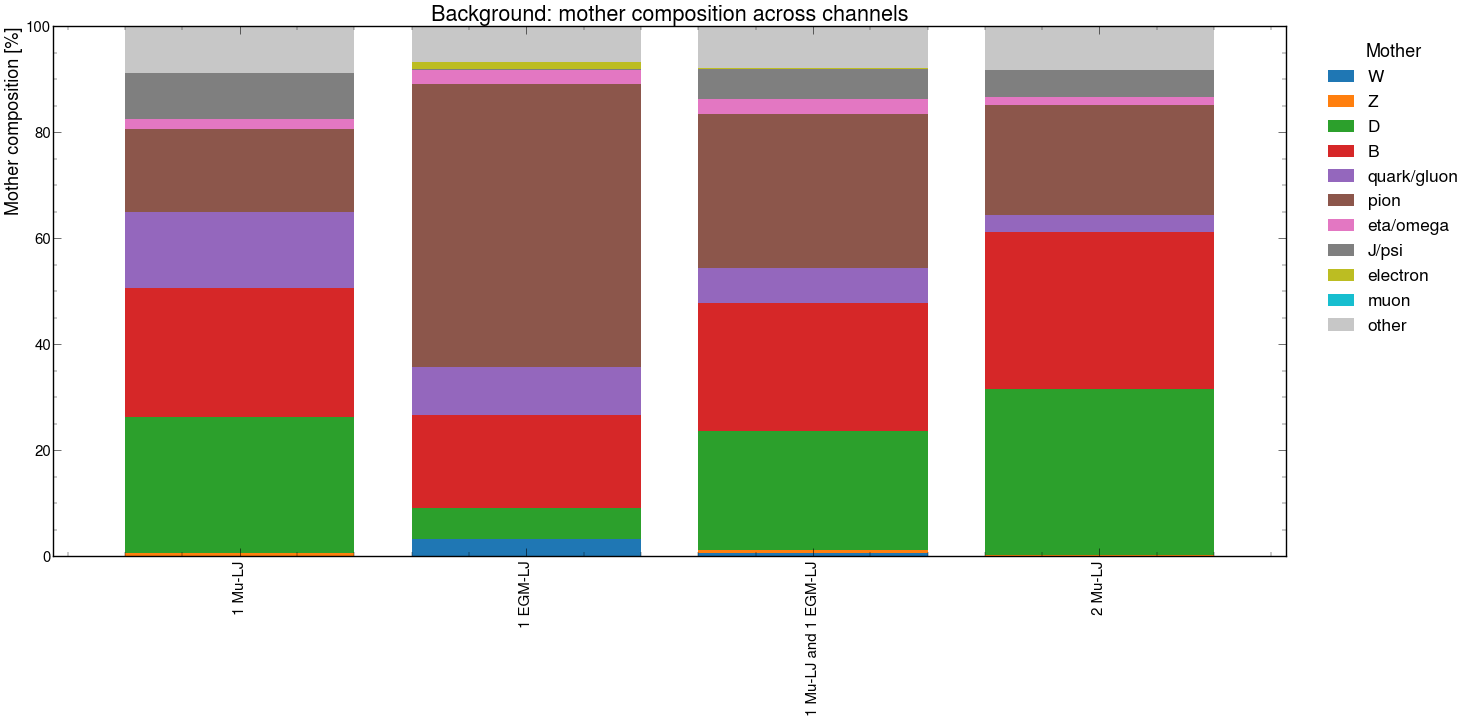

In [27]:
overall_mother_table = mother_composition_table(mother_out, background_samples)
display(overall_mother_table.round(2))
plot_mother_composition(overall_mother_table, f'{background_label}: mother composition across channels')

## Background: Signal-like mother composition

,W,Z,D,B,quark/gluon,pion,eta/omega,J/psi,electron,muon,other
1 Mu-LJ,0.02,0.55,18.63,18.86,29.70,14.02,1.96,5.17,0.00,0.16,10.92
1 EGM-LJ,2.08,0.06,0.65,3.33,23.56,64.32,3.33,0.00,0.73,0.42,1.52
1 Mu-LJ and 1 EGM-LJ,0.30,0.00,5.17,7.87,13.24,37.39,0.00,21.69,0.00,0.00,14.33
2 Mu-LJ,66.35,0.09,0.05,0.05,0.00,0.16,0.00,0.00,0.05,33.18,0.05


## Background: Bkg-like mother composition

,W,Z,D,B,quark/gluon,pion,eta/omega,J/psi,electron,muon,other
1 Mu-LJ,0.02,0.05,27.48,26.36,10.39,16.51,2.26,8.30,0.00,0.04,8.59
1 EGM-LJ,2.08,0.00,9.23,28.68,5.27,42.43,3.49,0.12,0.84,0.00,7.87
1 Mu-LJ and 1 EGM-LJ,0.33,0.00,23.68,27.99,6.04,27.21,2.27,6.34,0.13,0.05,5.96
2 Mu-LJ,0.05,0.00,33.11,29.37,2.97,20.69,1.22,4.52,0.00,0.03,8.04


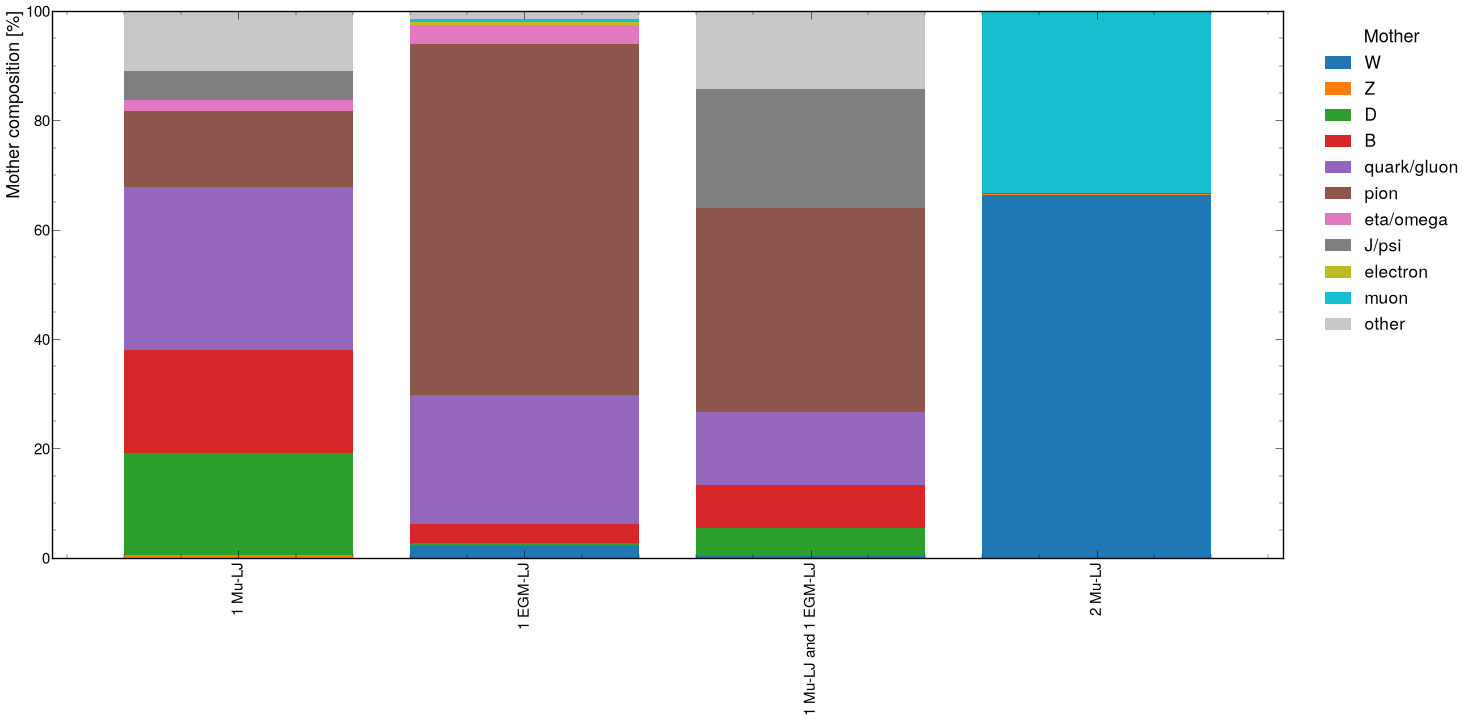

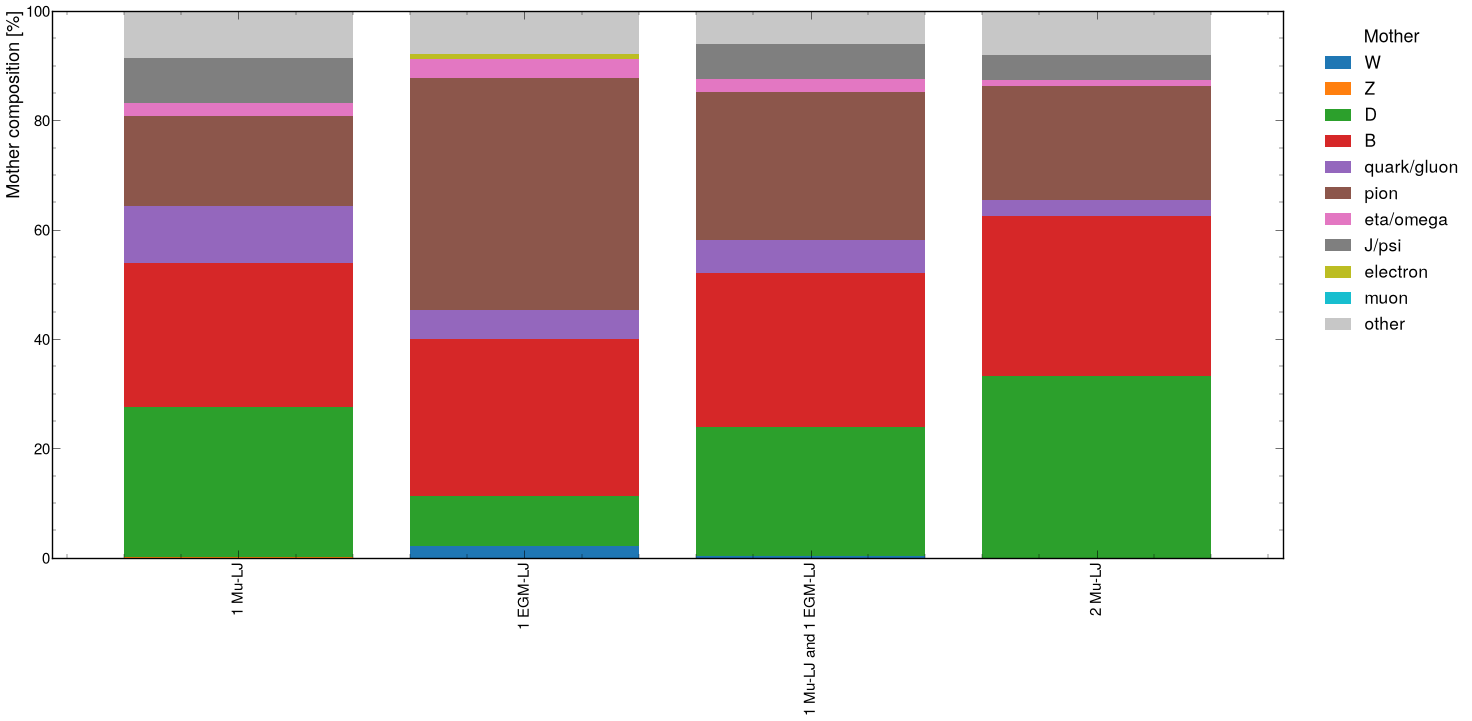

In [9]:
region_mother_tables = {}

for region in ['both_pass', 'both_fail']:
    table = mother_composition_table_for_region(mother_out, background_samples, region)
    region_mother_tables[region] = table
    display(Markdown(f"## {background_label}: {REGION_LABELS[region]} mother composition"))
    display(table.round(2))
    plot_mother_composition(
        table,
        None,
    )

In [29]:
mu_lj_variables = [
    'mu_lj_pt',
    'mu_lj_eta',
    "mu_lj_phi",
    'mu_lj_mass_small',
    'mu_lj_iso',
    'mu_lj_dRSpread',
    'mu_lj_muonN',
    'mu_lj_pfMu_n',
    'mu_lj_dsaMu_n',
]

egm_lj_variables = [
    'egm_lj_pt',
    'egm_lj_eta',
    "egm_lj_phi",
    'egm_lj_mass_small',
    'egm_lj_iso',
    'egm_lj_dRSpread',
    'egm_lj_electronN',
    'egm_lj_photonN',
]

mu_channels = ['1 Mu-LJ', '1 Mu-LJ and 1 EGM-LJ', '2 Mu-LJ']
egm_channels = ['1 EGM-LJ', '1 Mu-LJ and 1 EGM-LJ']

PLOT_OPTIONS = {
    'mu_lj_mass_small': {'xlim': (0, 6)},
    'egm_lj_mass_small': {'xlim': (0, 6)},
    'mu_lj_dRSpread': {'rebin': 5},
    'egm_lj_dRSpread': {'rebin': 5},
    'mu_lj_pt': {'xlim': (0, 200)},
    'egm_lj_pt': {'xlim': (0, 200)},
}

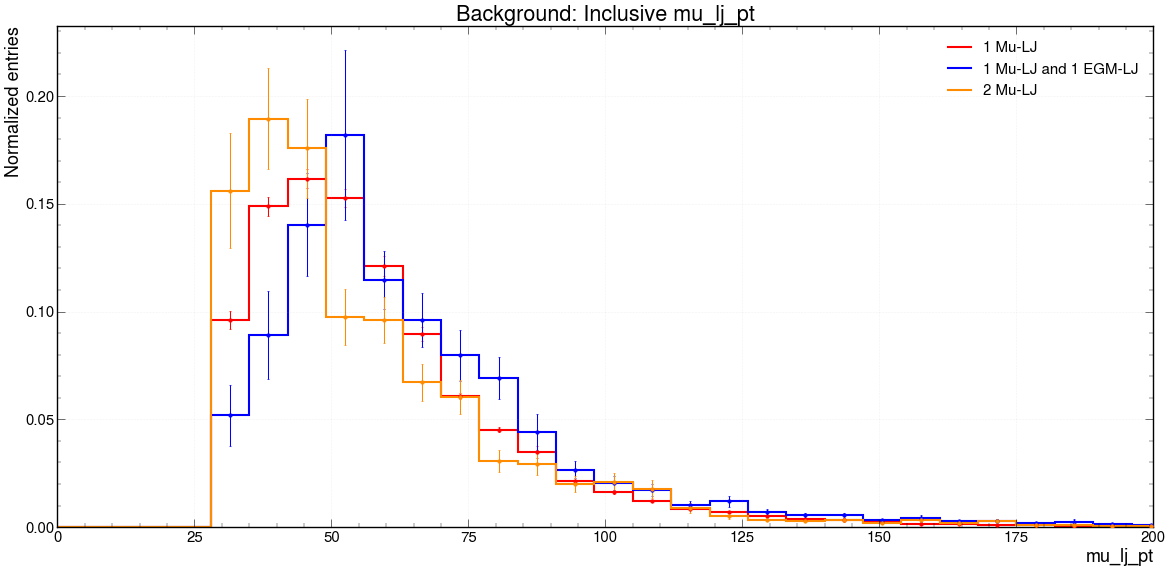

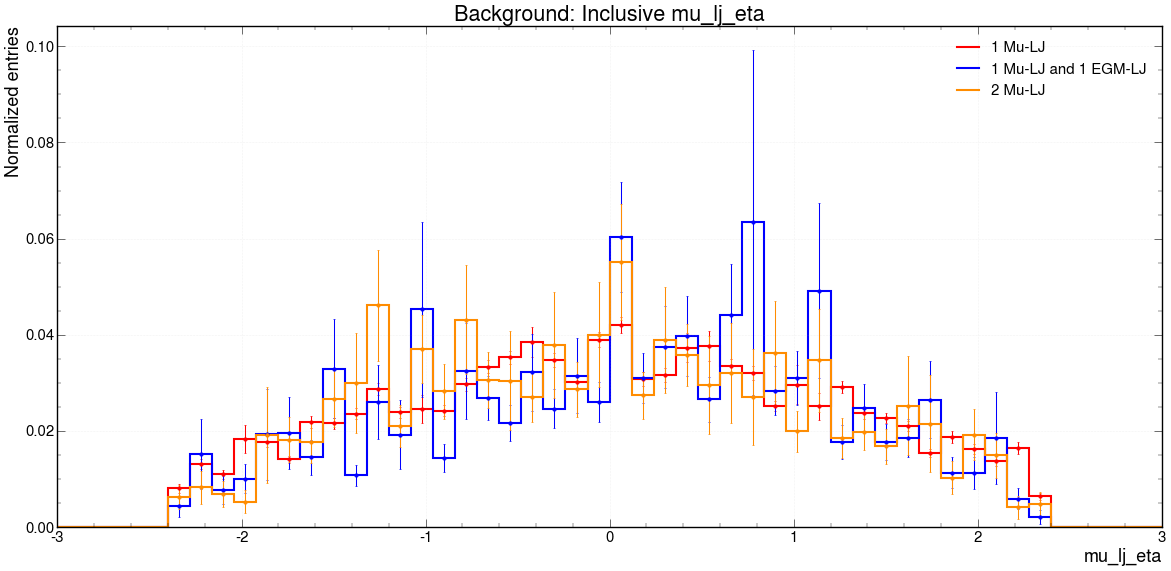

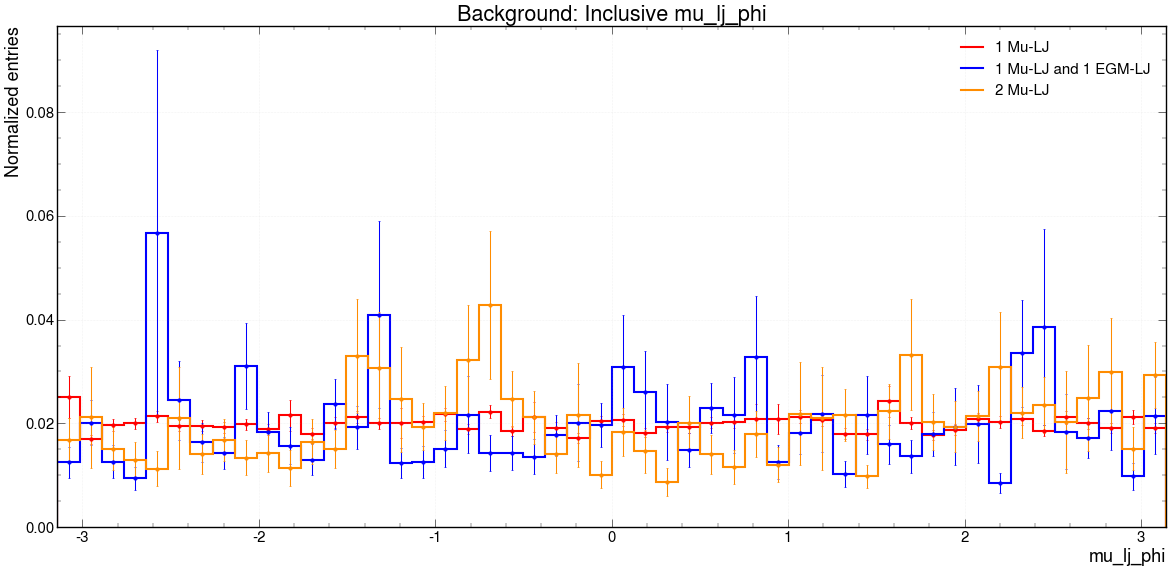

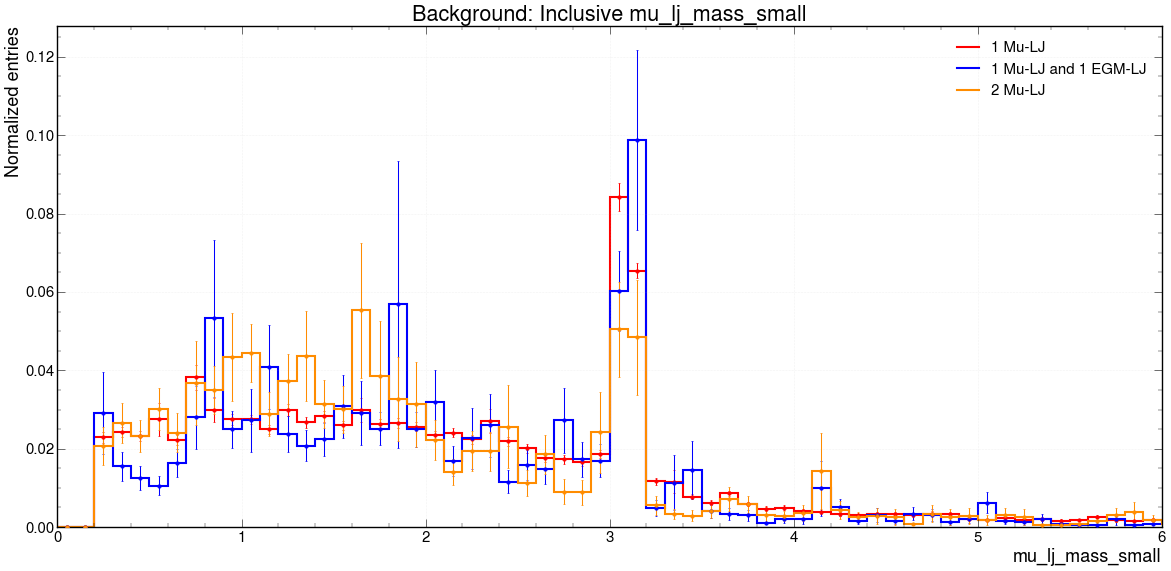

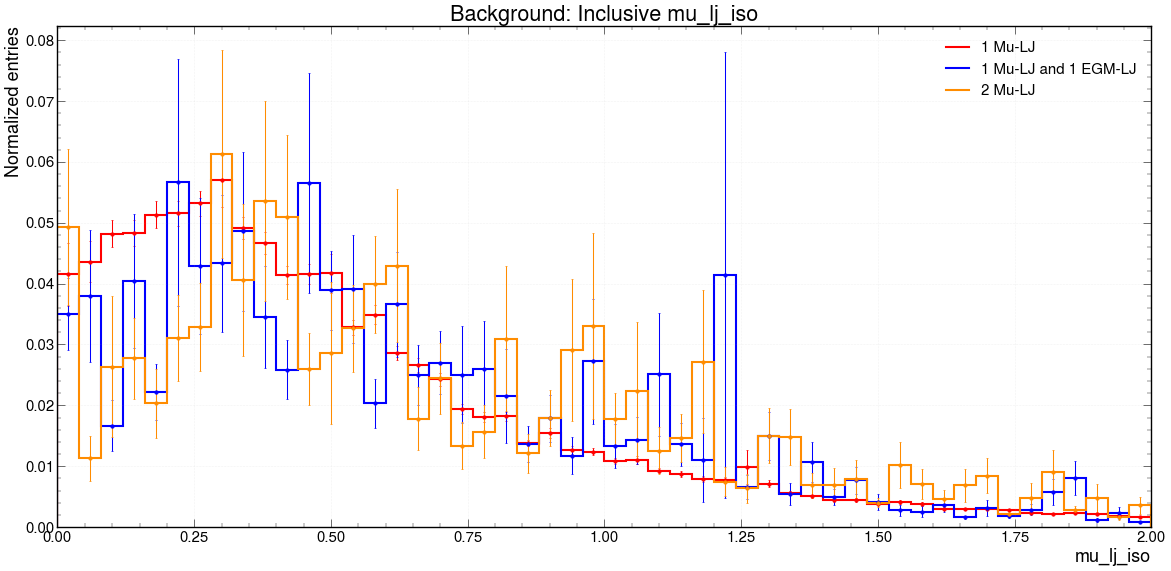

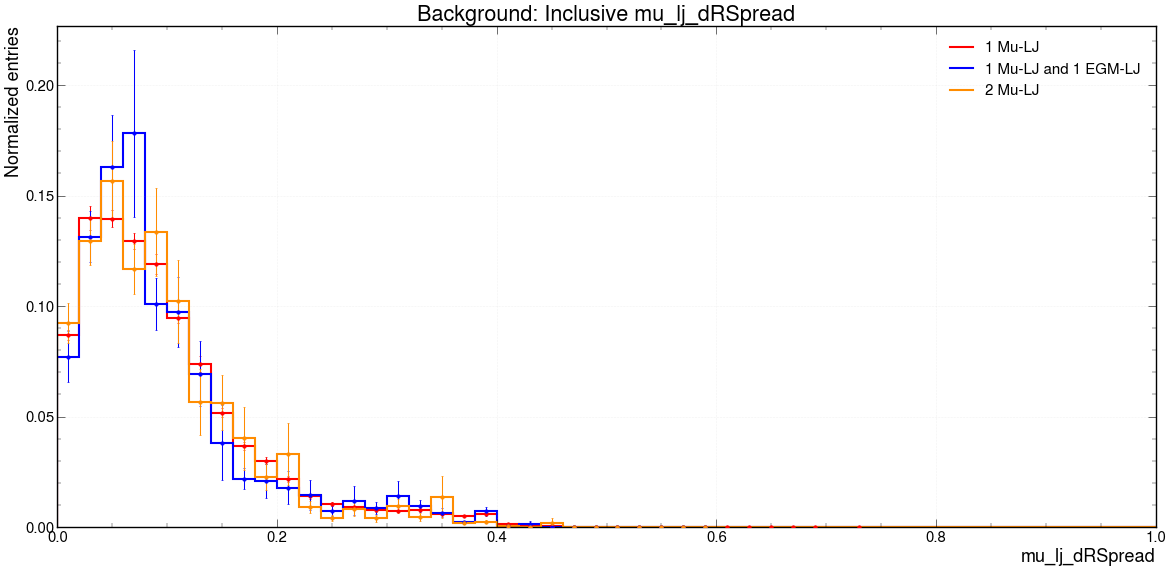

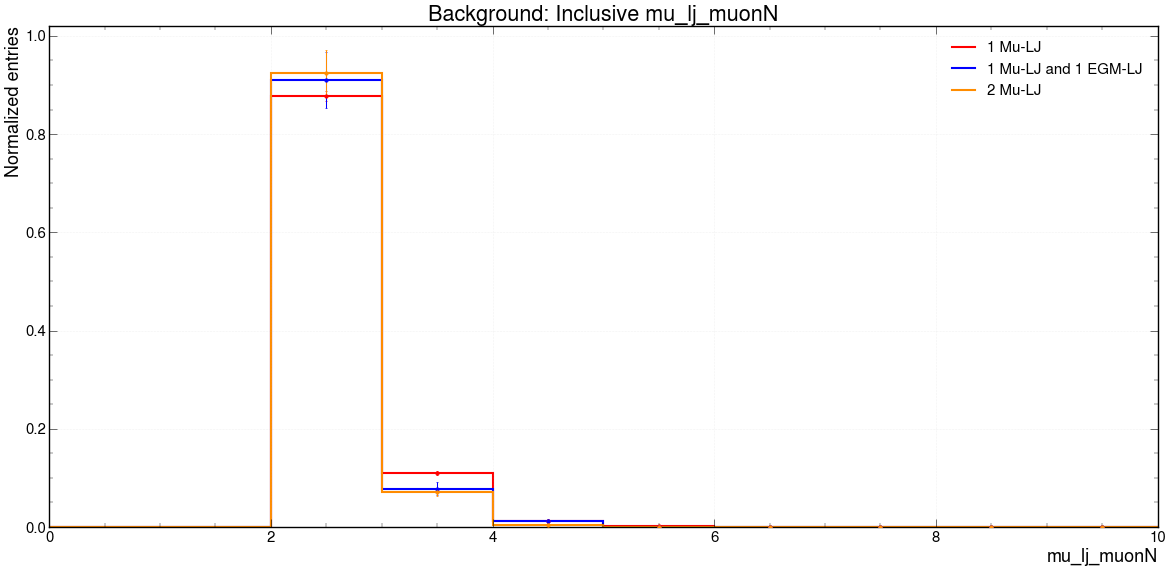

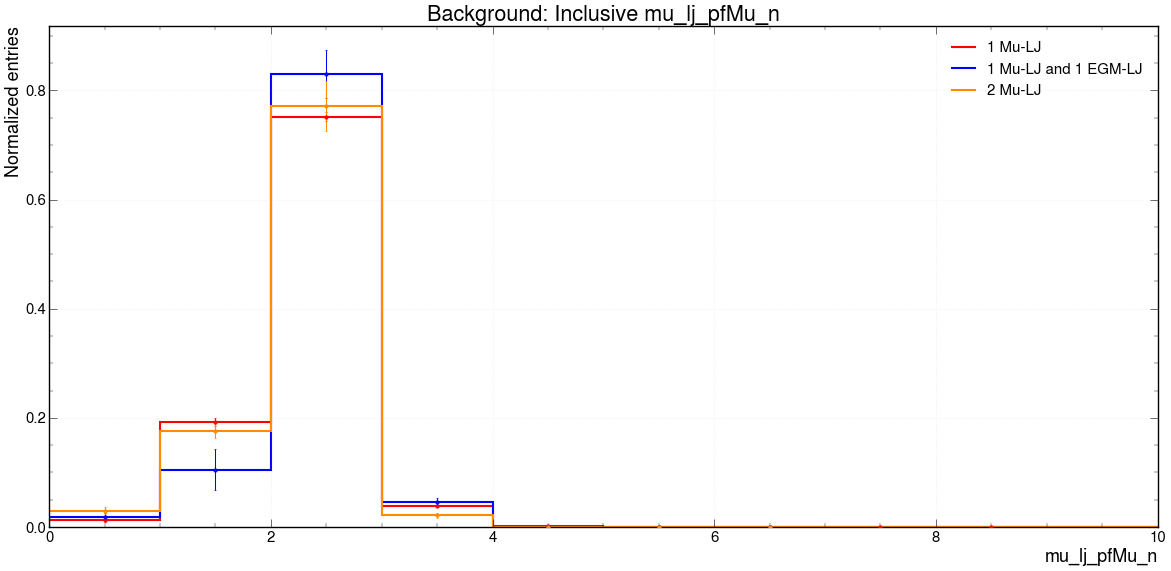

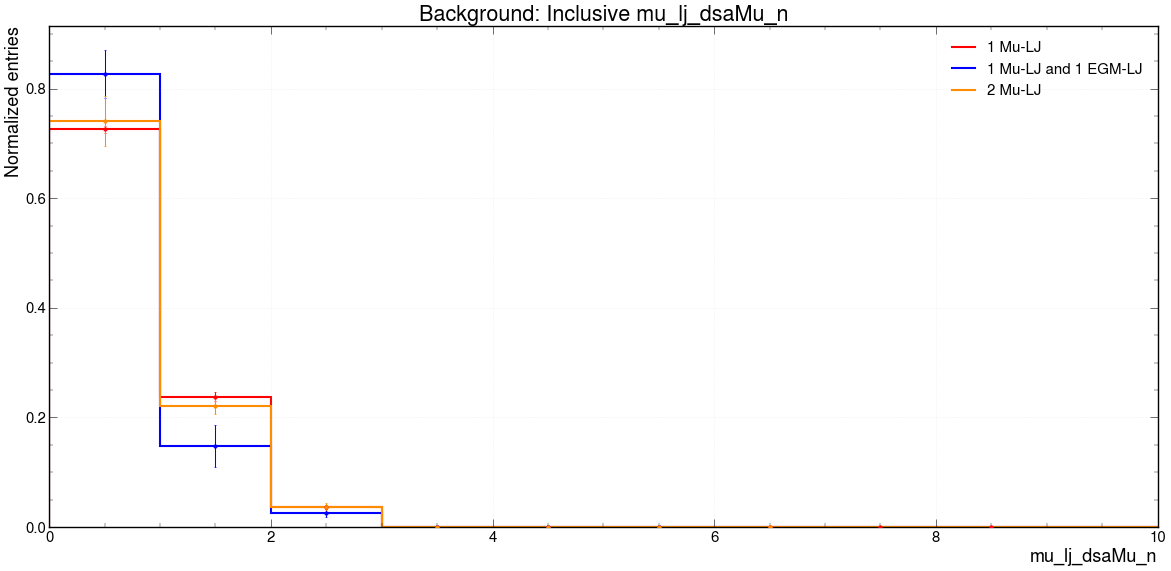

In [30]:
for variable in mu_lj_variables:
    plot_shape(mu_channels, background_samples, variable, title=f'{background_label}: Inclusive {variable}', show_errors=True, **PLOT_OPTIONS.get(variable, {}))

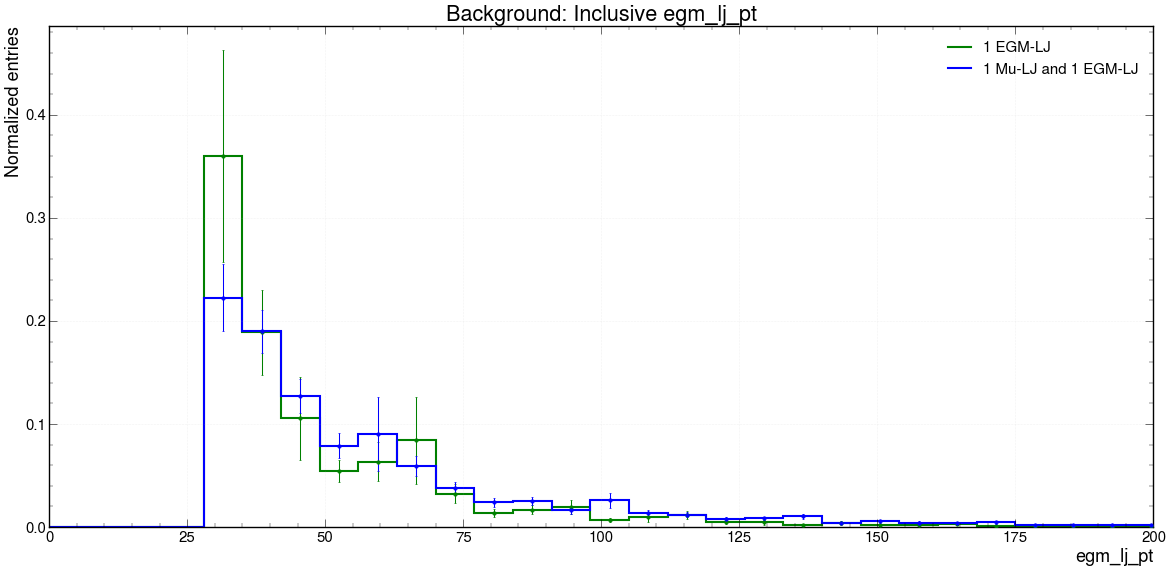

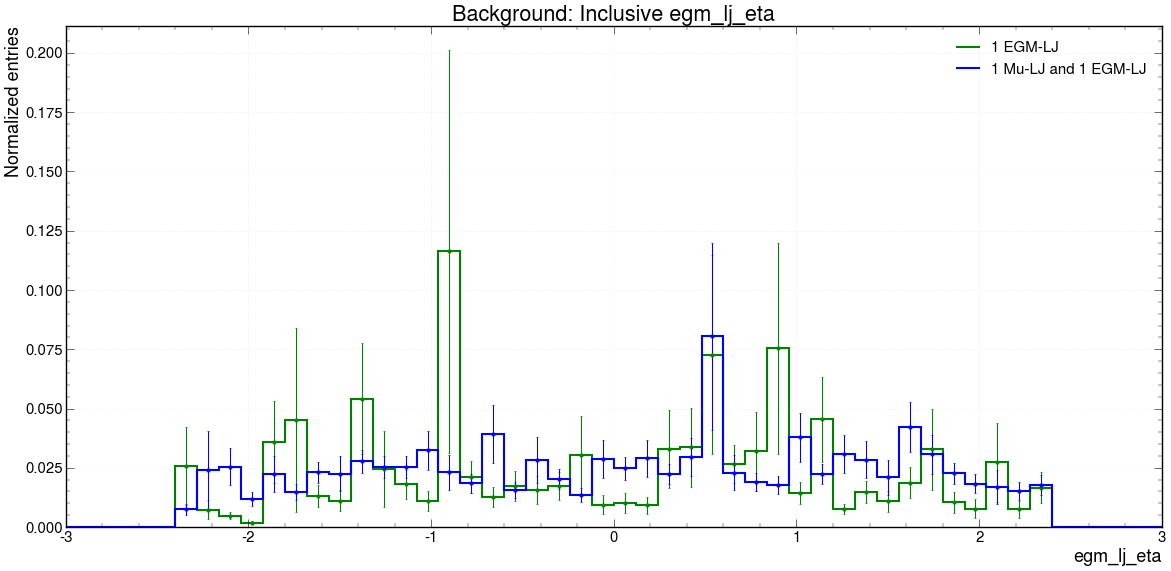

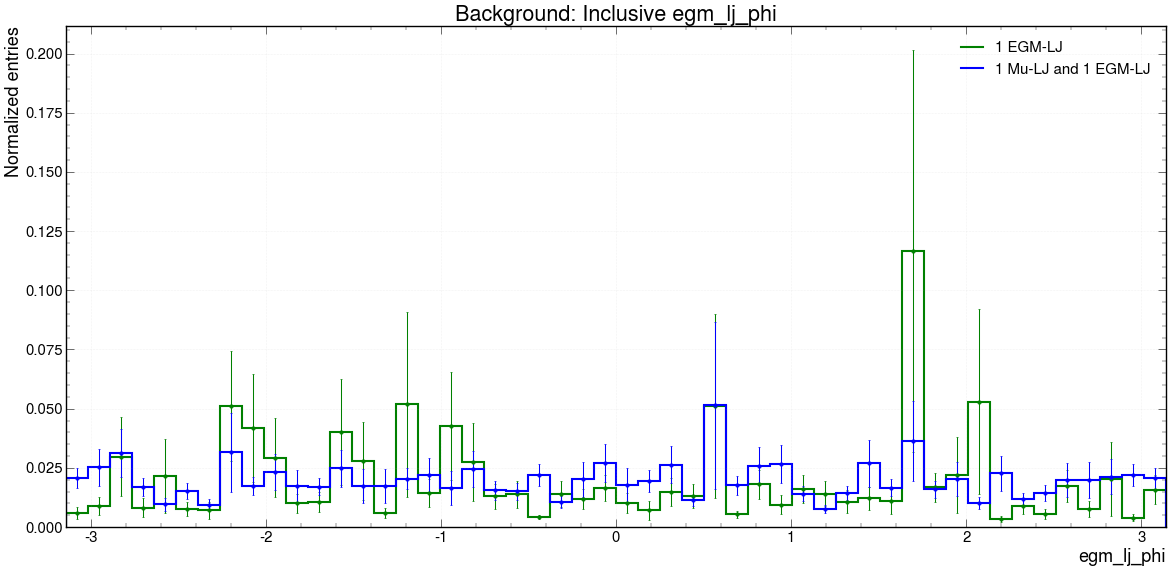

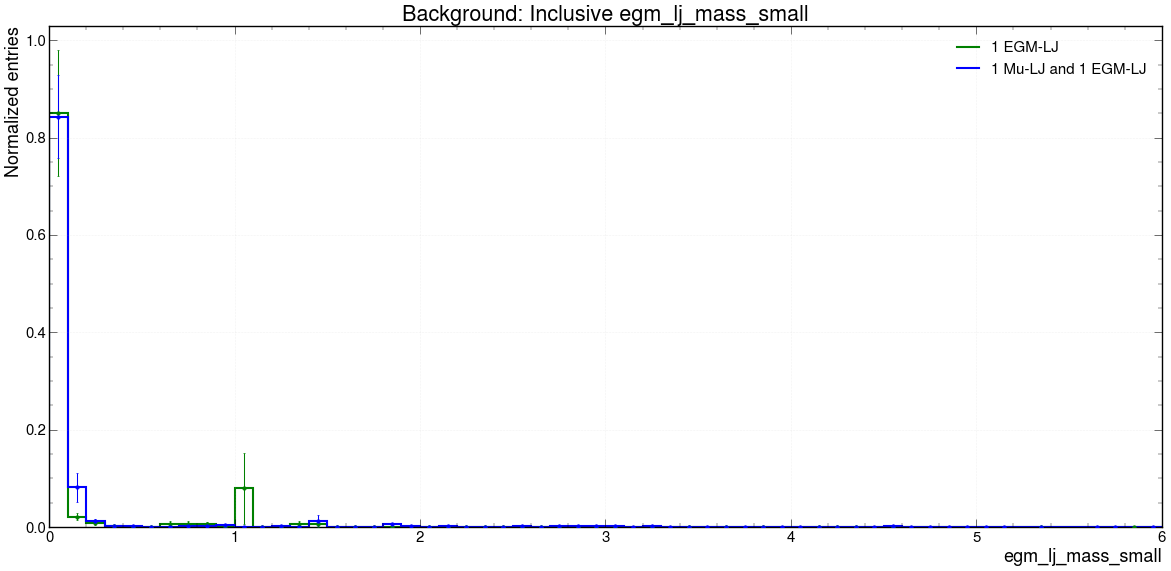

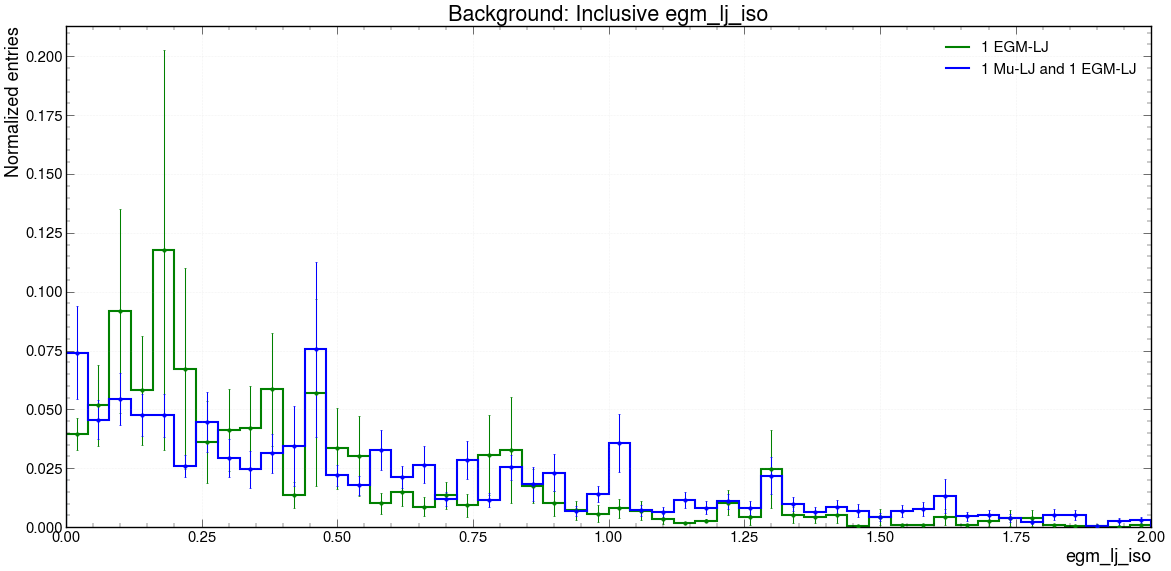

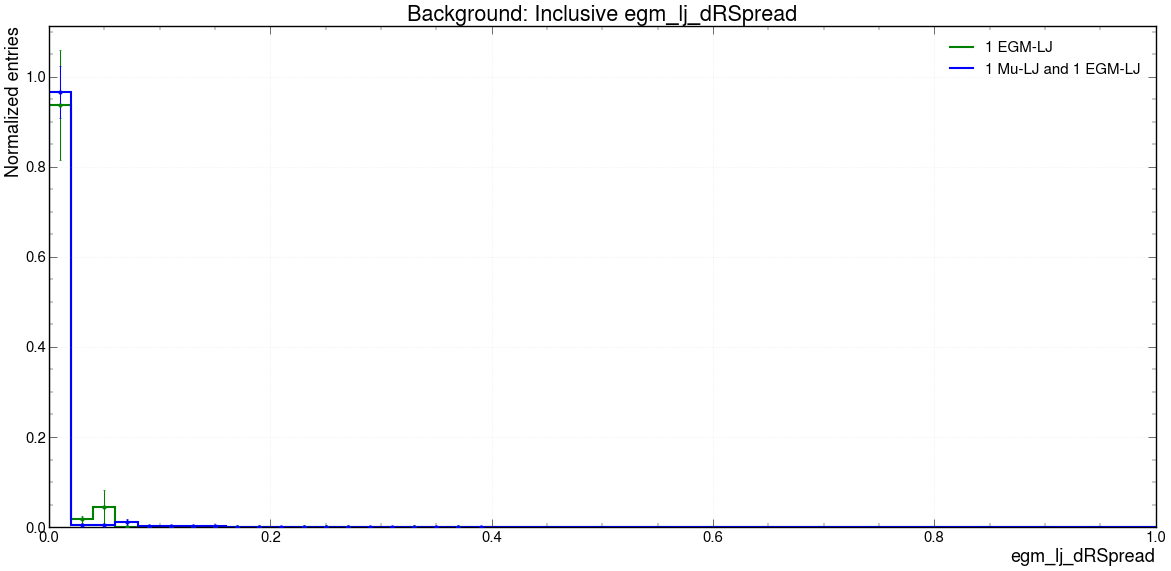

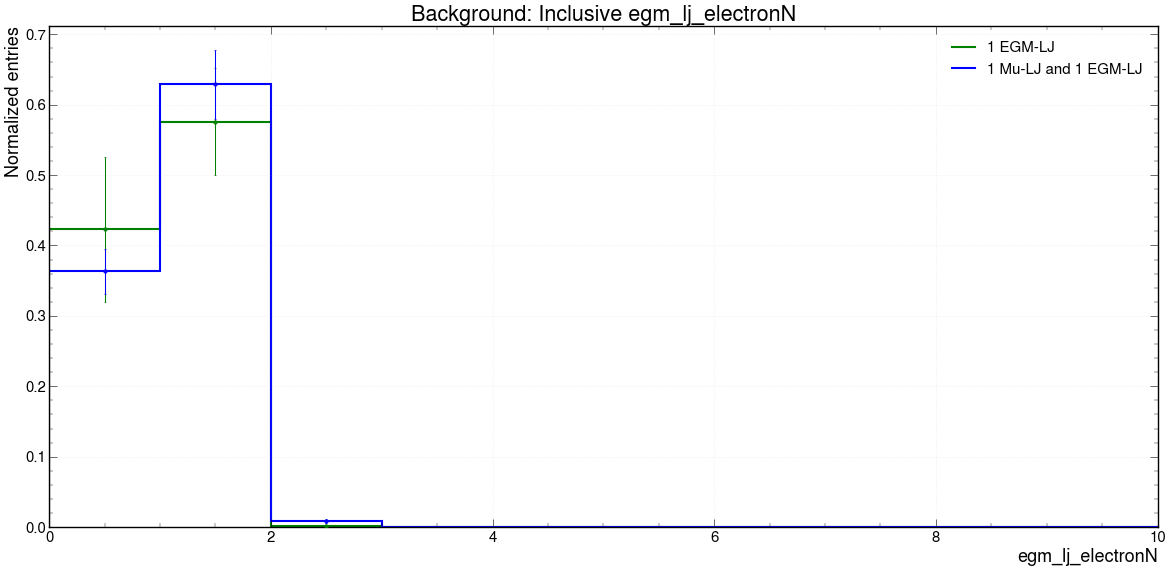

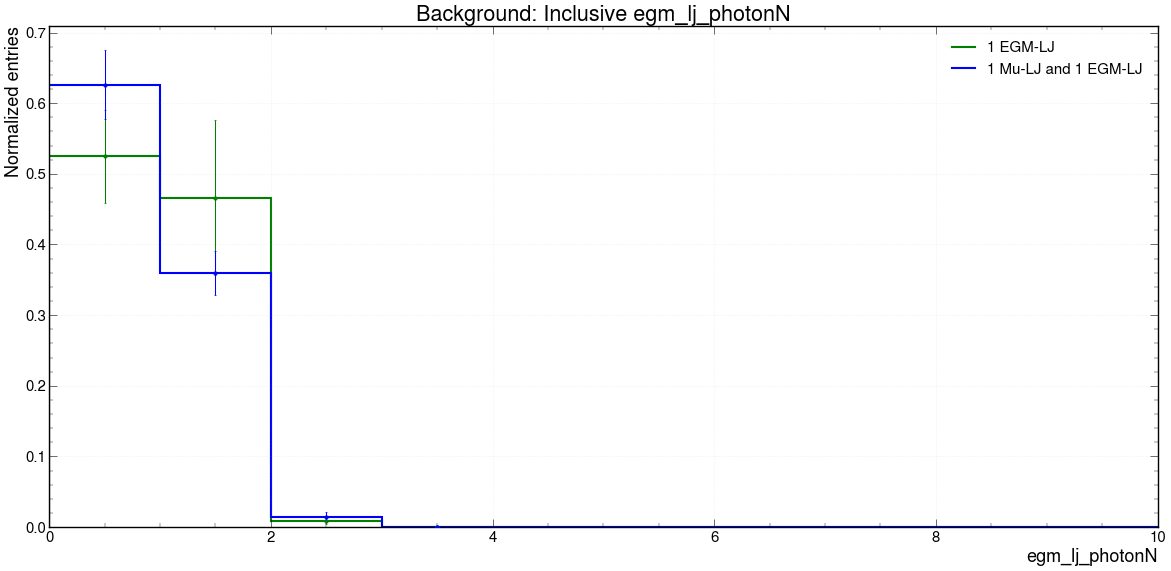

In [31]:
for variable in egm_lj_variables:
    plot_shape(egm_channels, background_samples, variable, title=f'{background_label}: Inclusive {variable}', show_errors=True, **PLOT_OPTIONS.get(variable, {}))

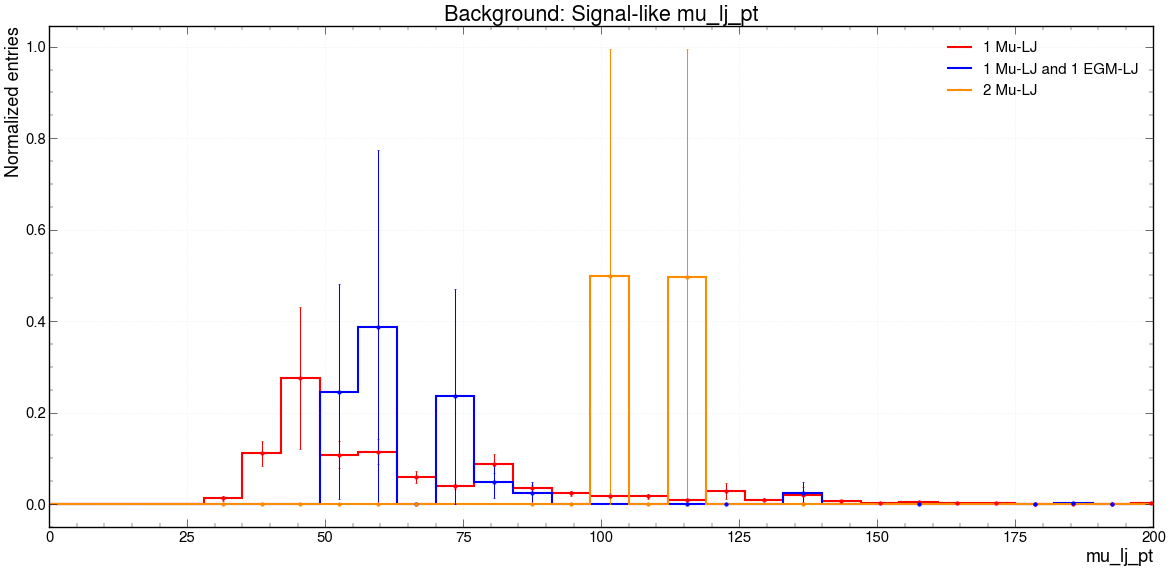

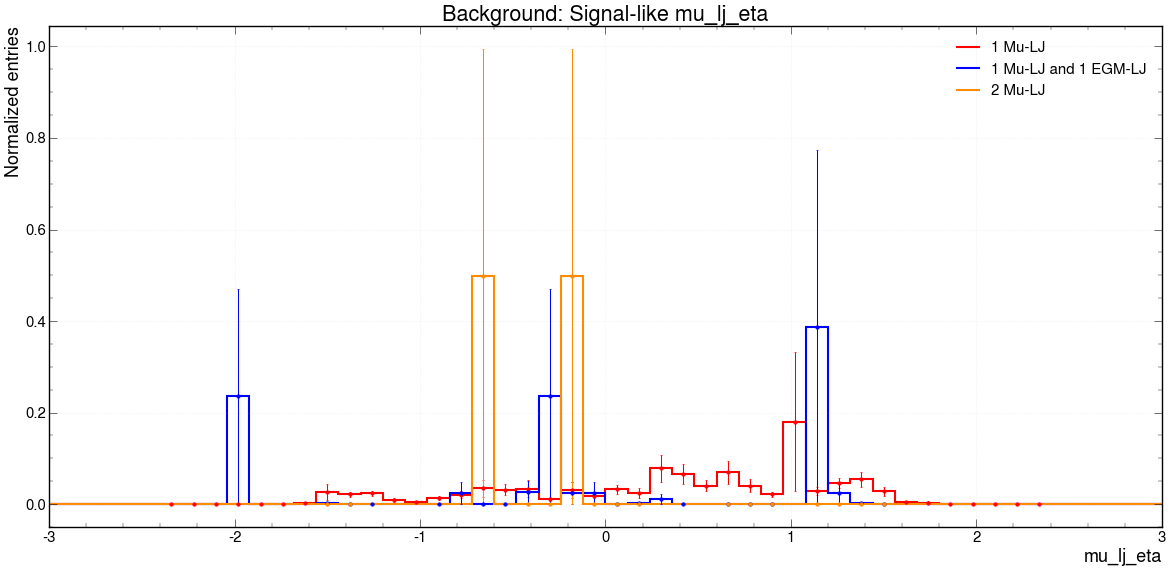

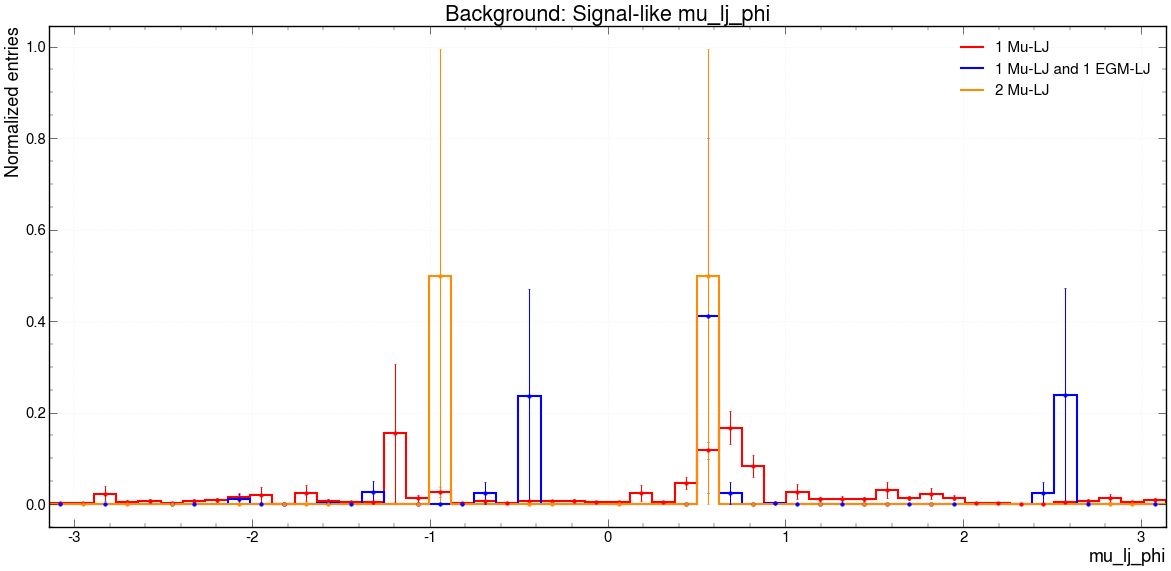

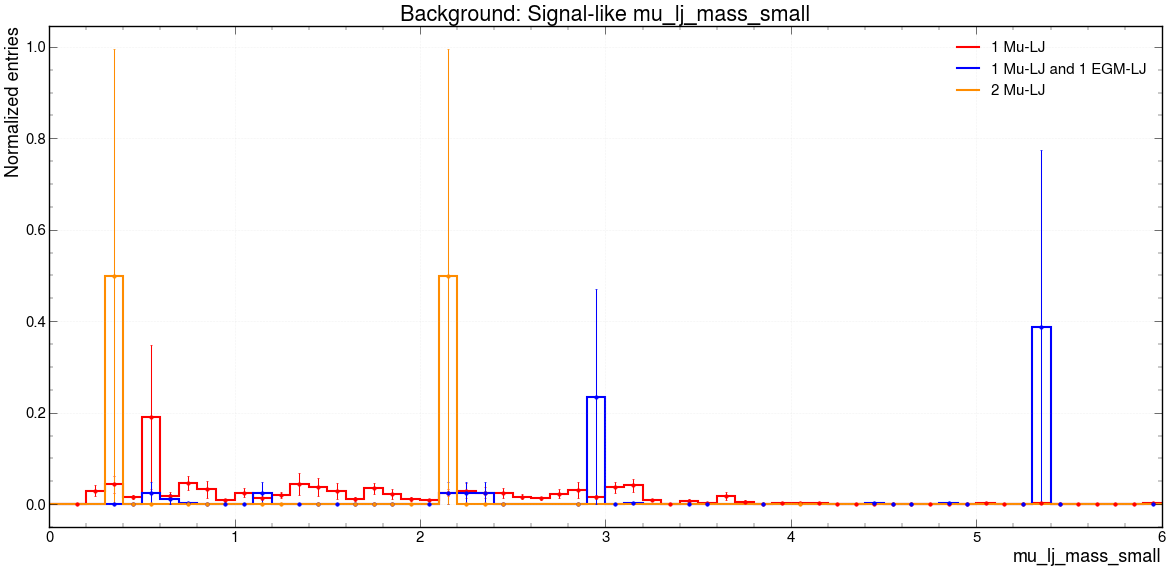

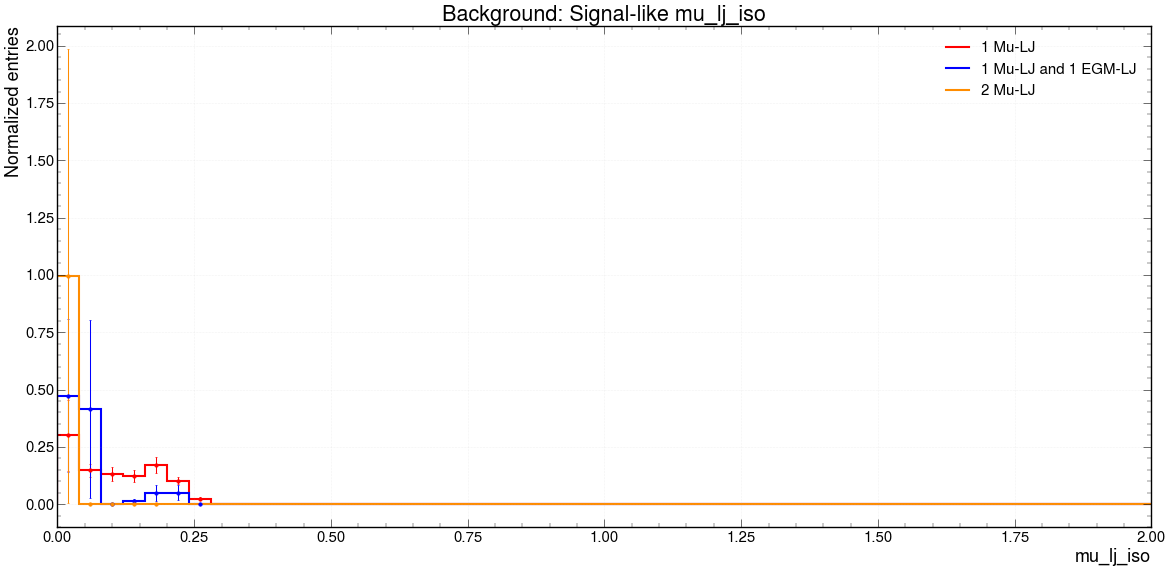

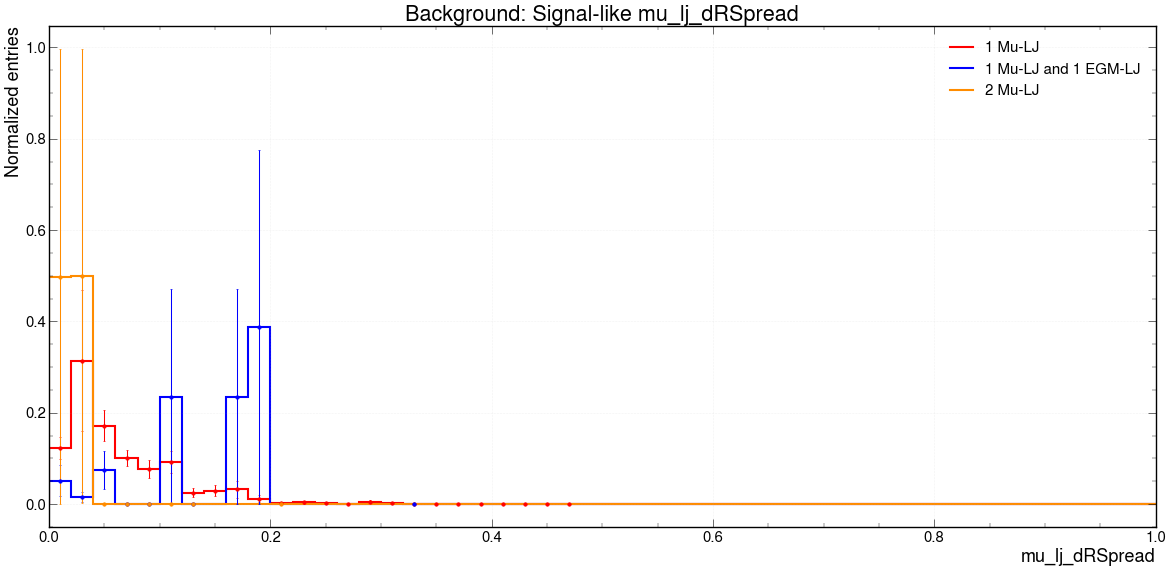

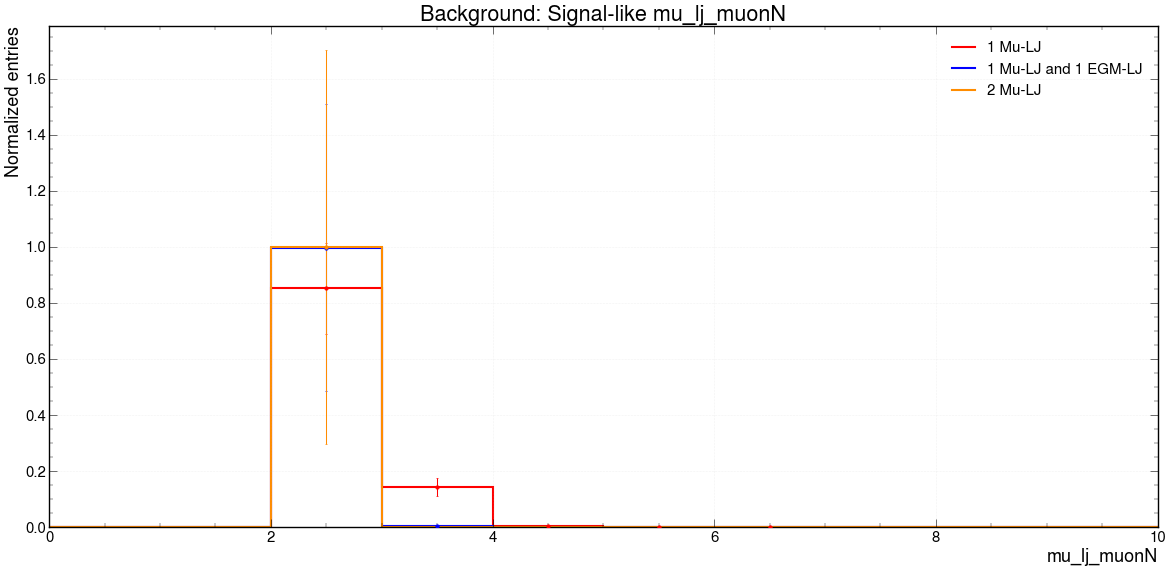

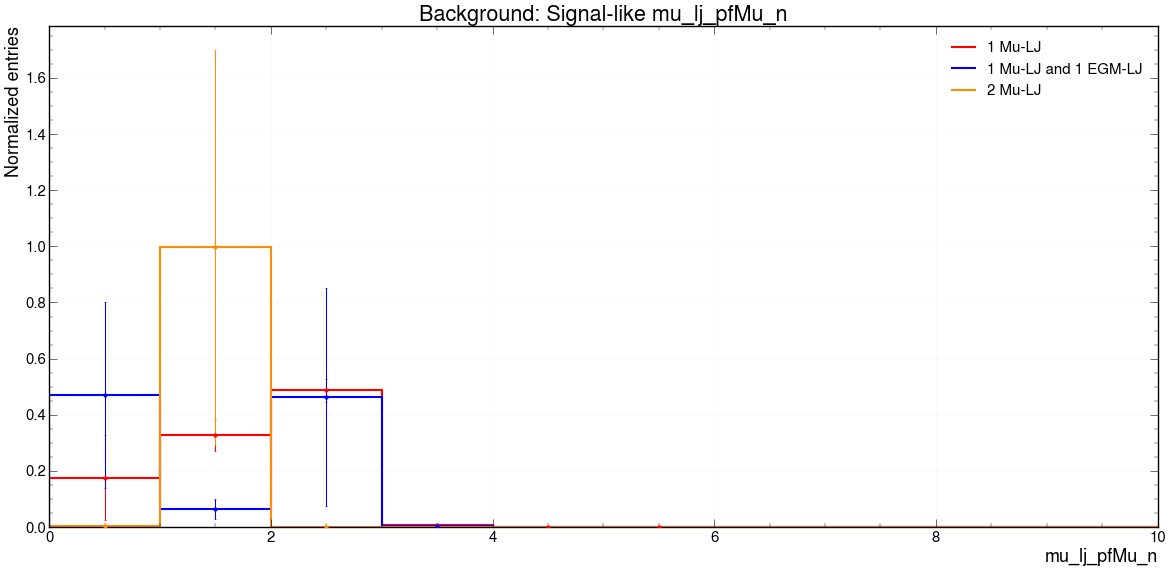

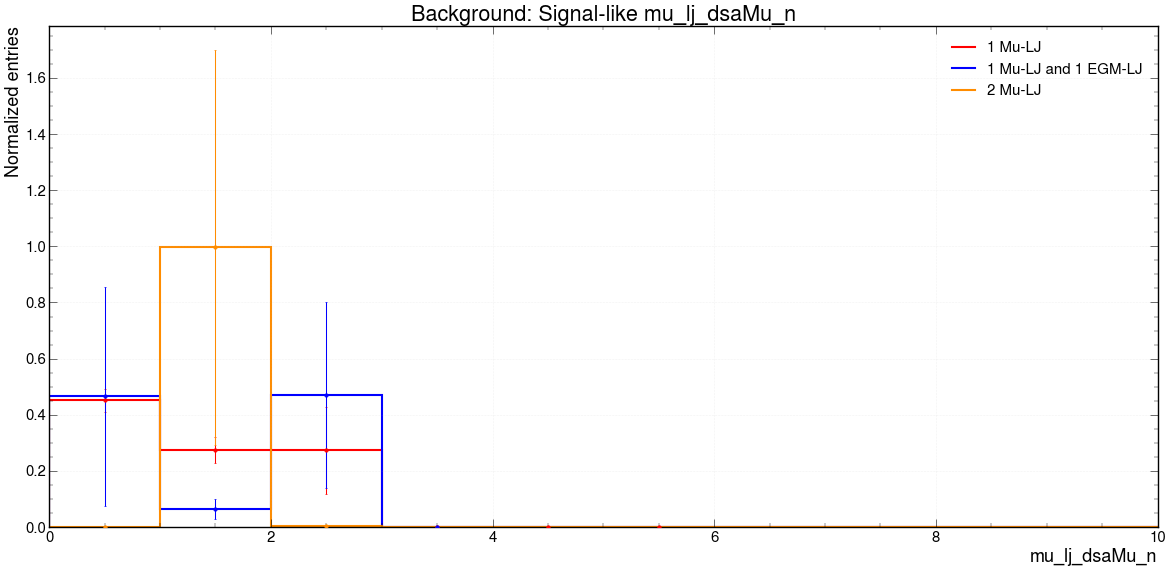

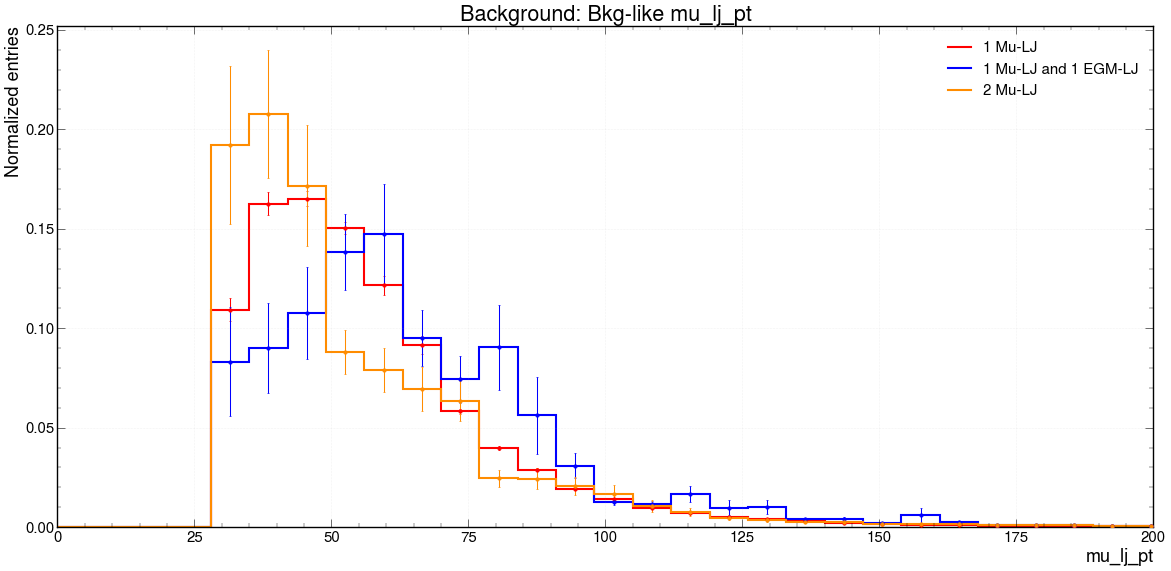

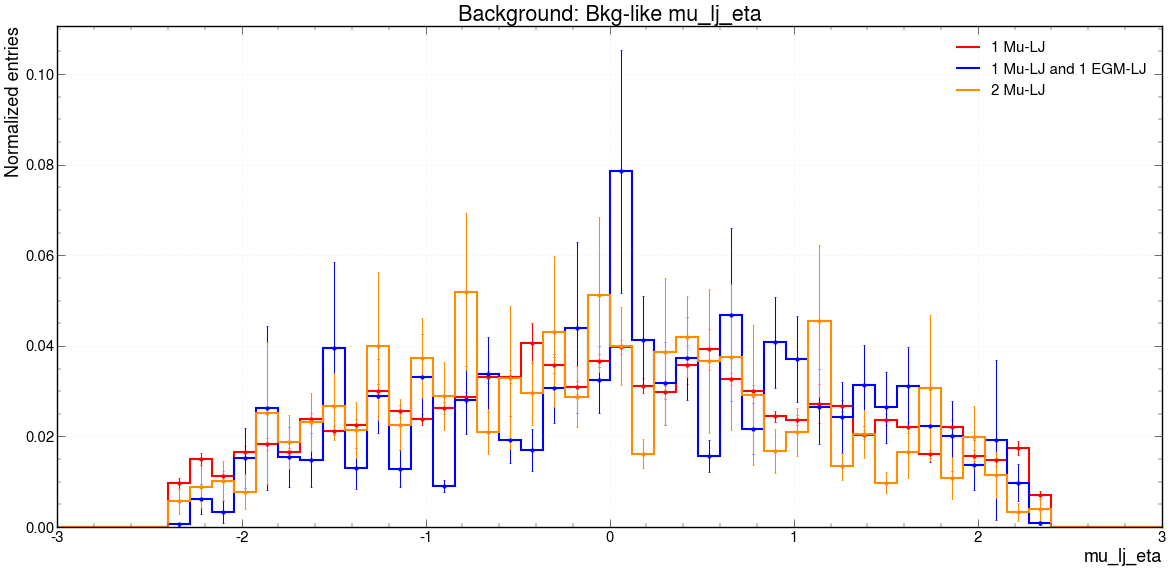

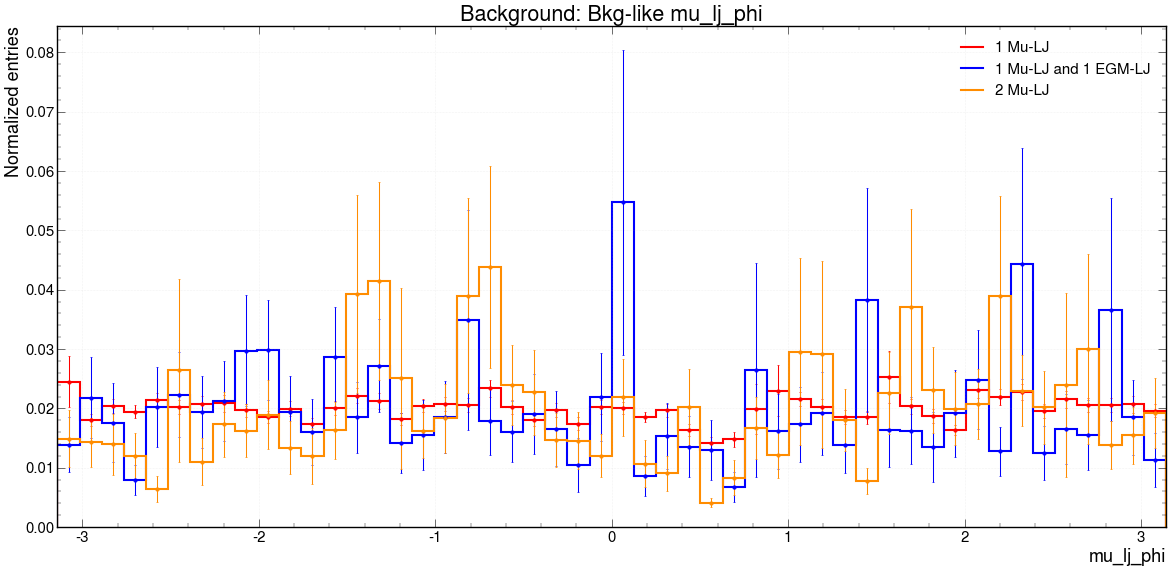

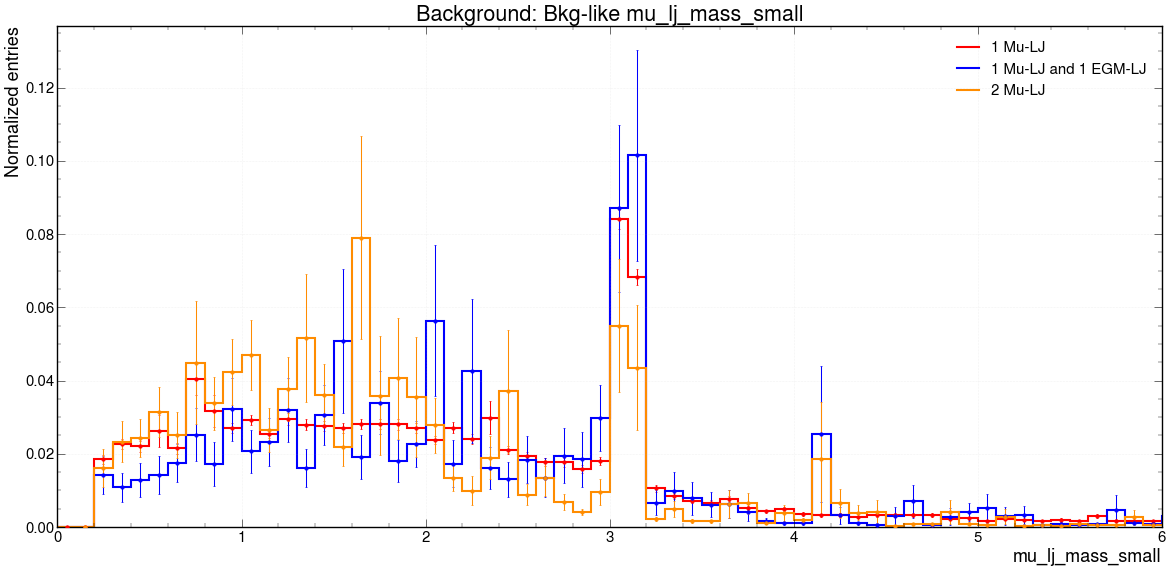

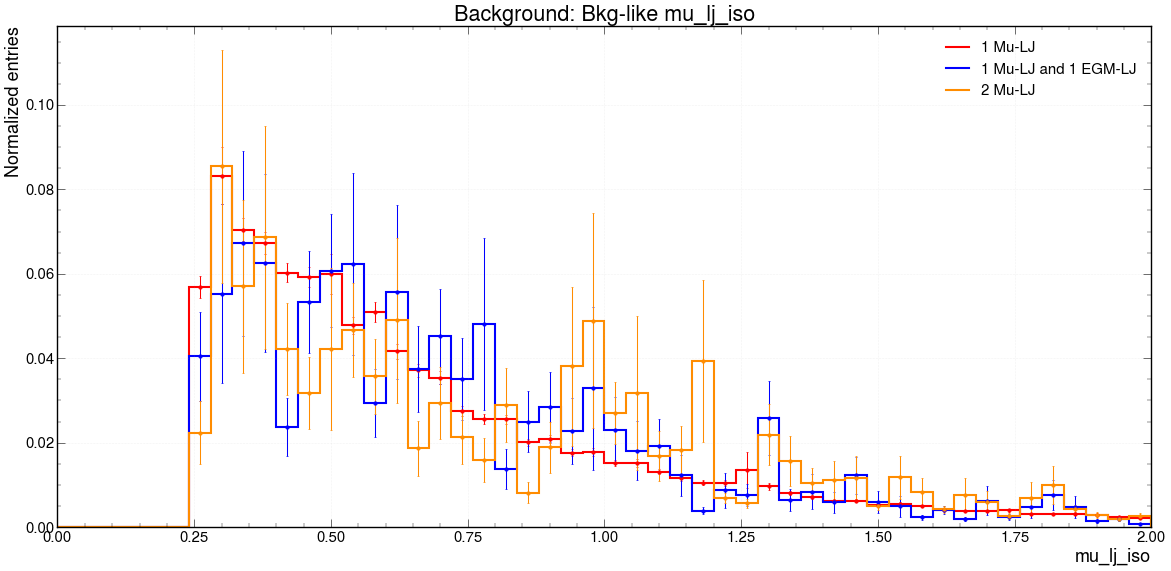

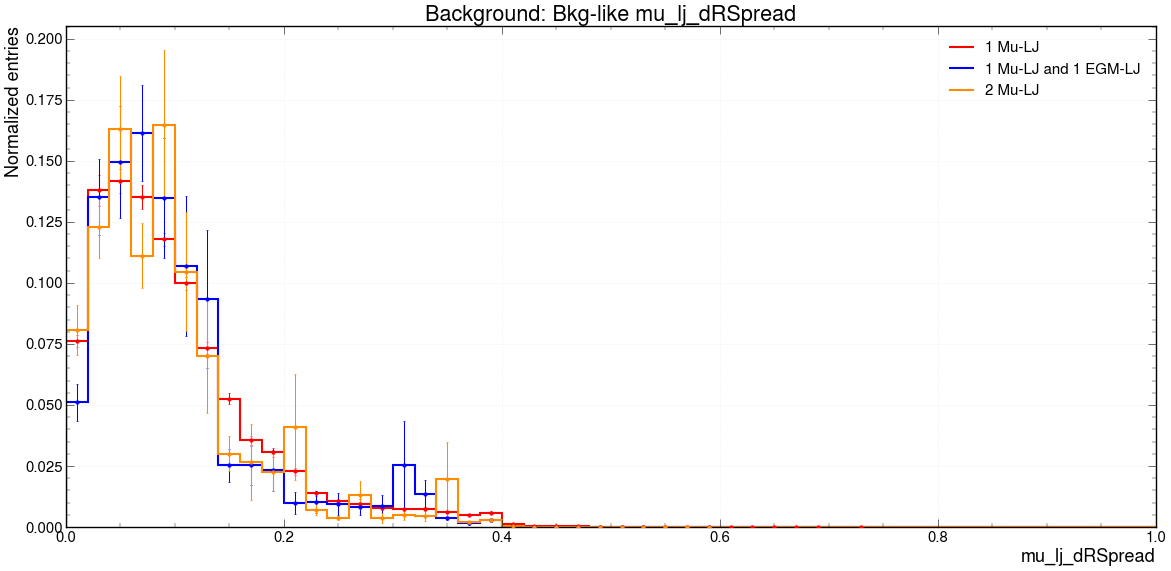

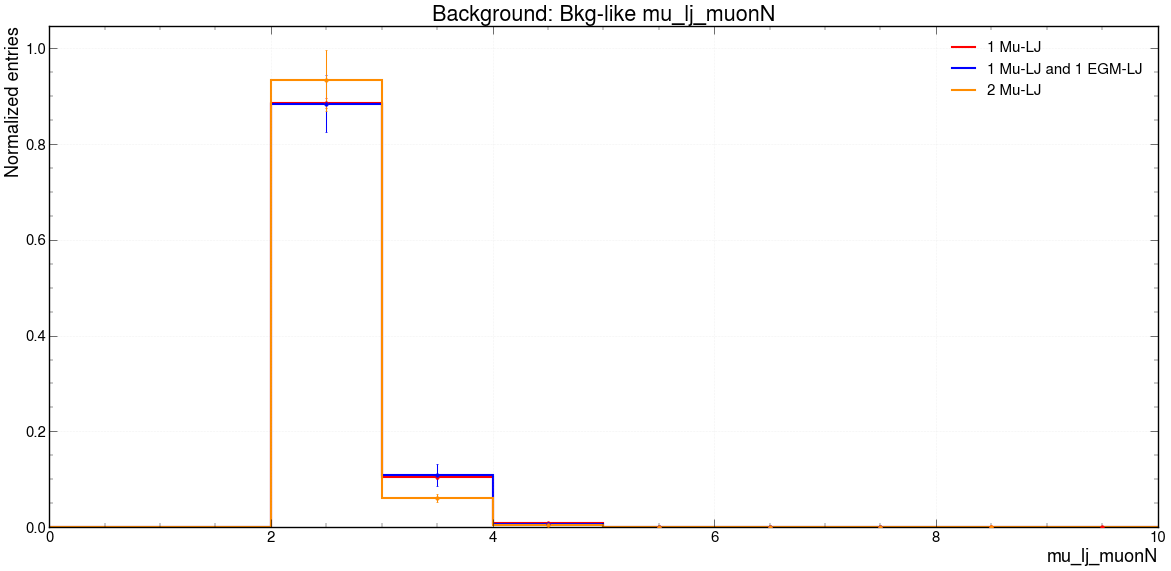

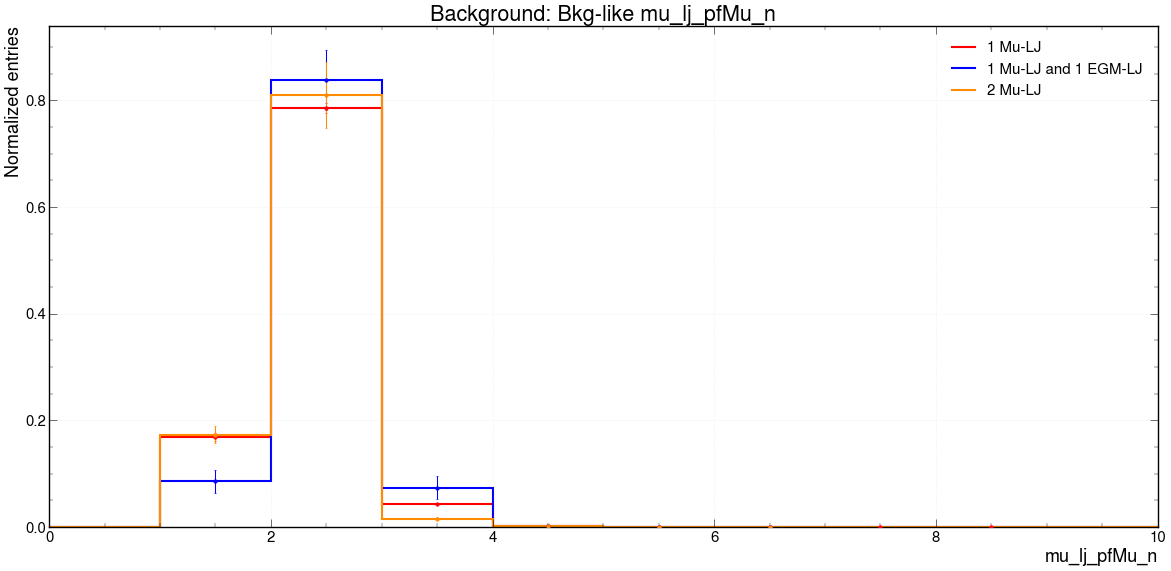

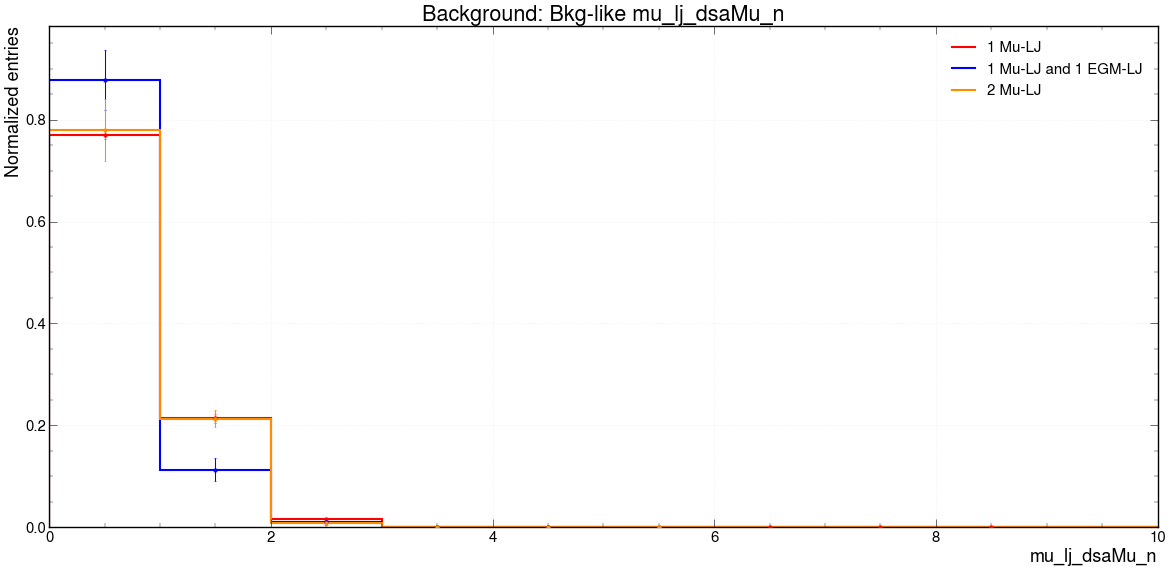

In [32]:
for region in ['both_pass', 'both_fail']:
    for variable in mu_lj_variables:
        plot_shape_for_region(
            mu_channels,
            background_samples,
            variable,
            region=region,
            title=f'{background_label}: {REGION_LABELS[region]} {variable}',
            show_errors=True,
            **PLOT_OPTIONS.get(variable, {}),
        )


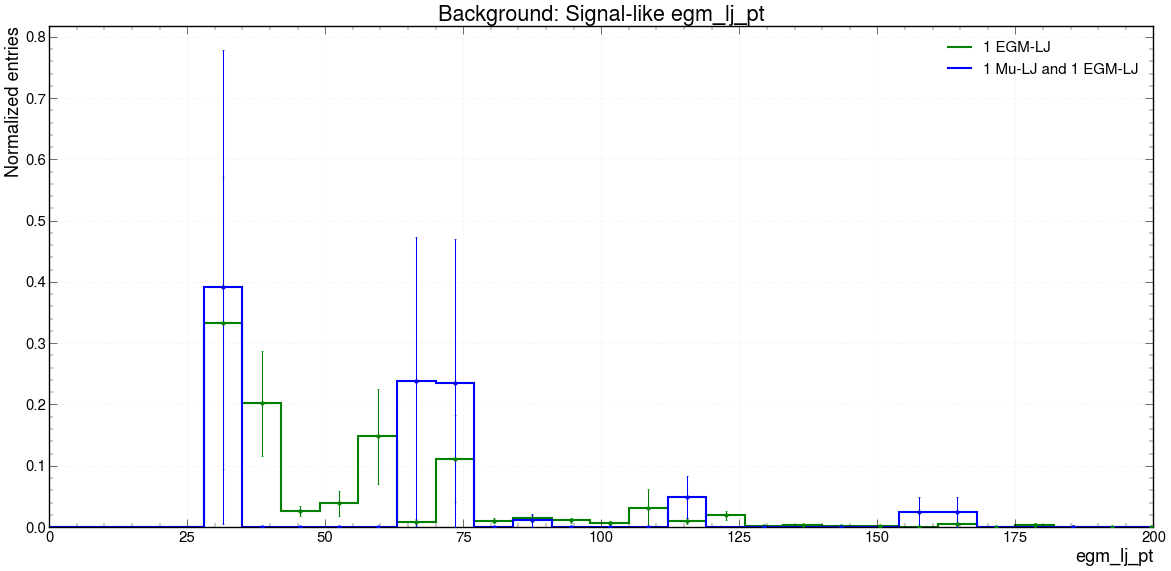

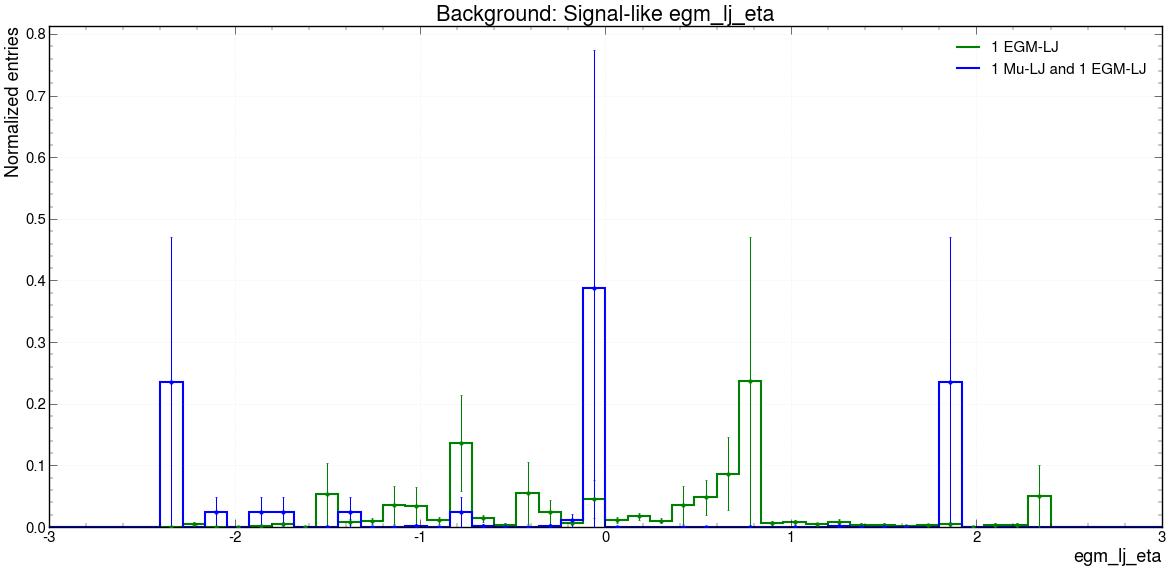

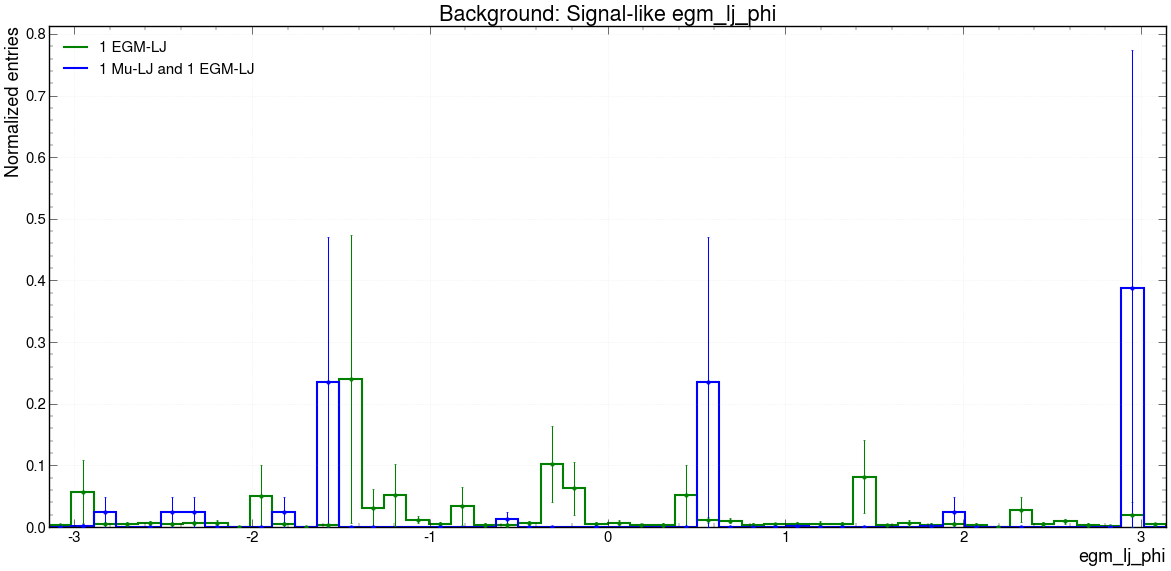

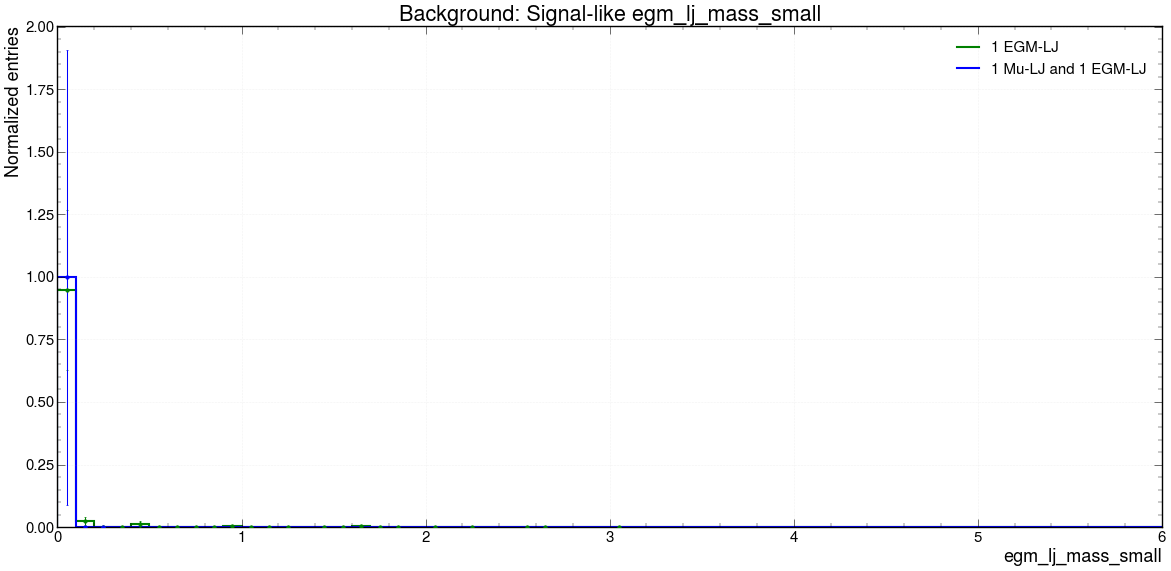

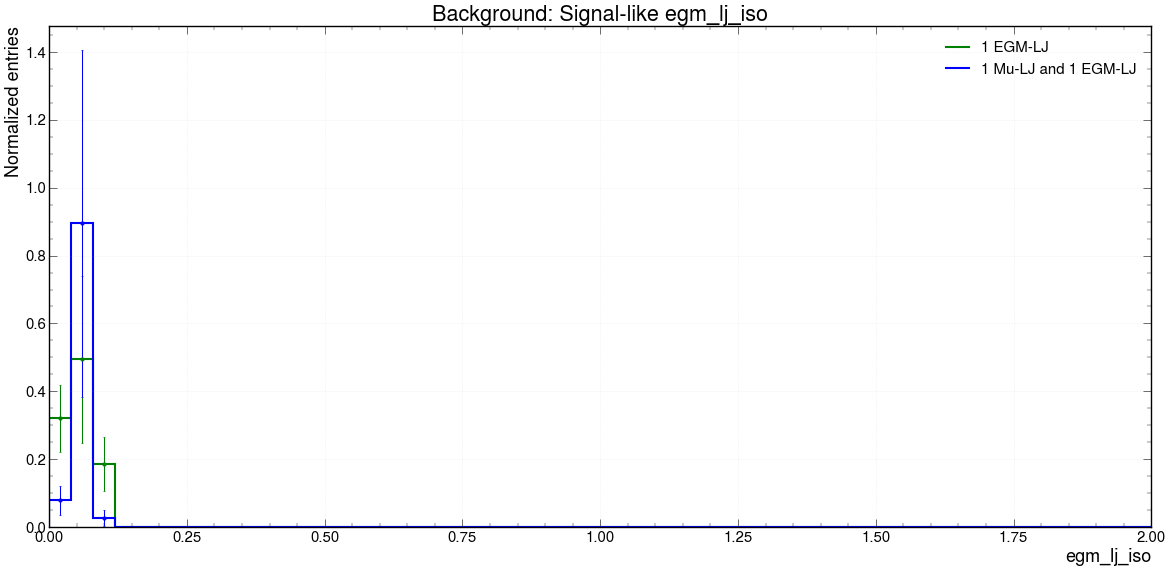

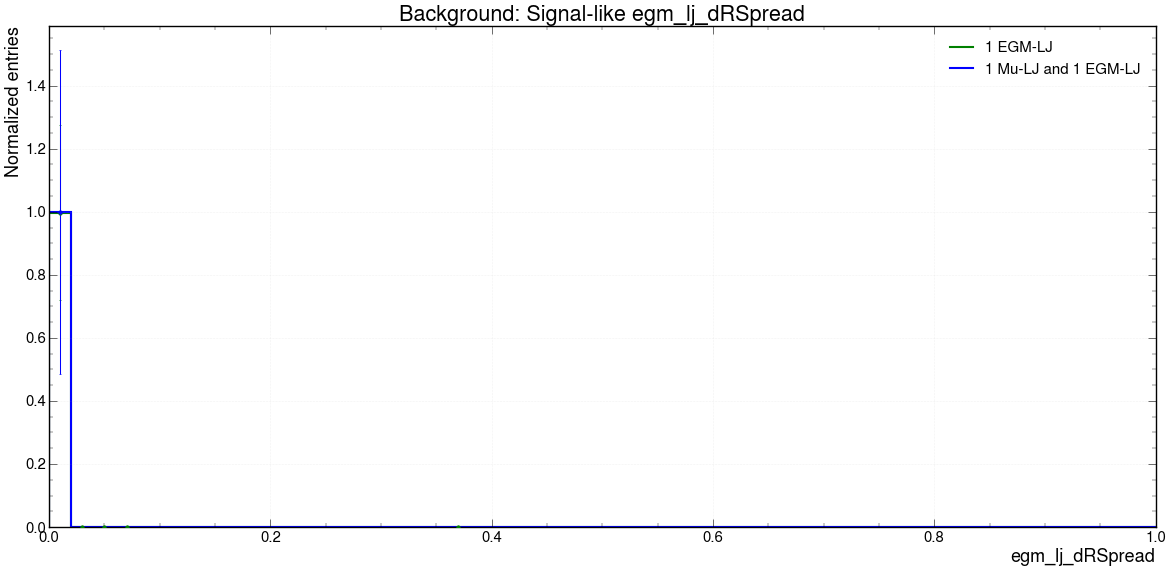

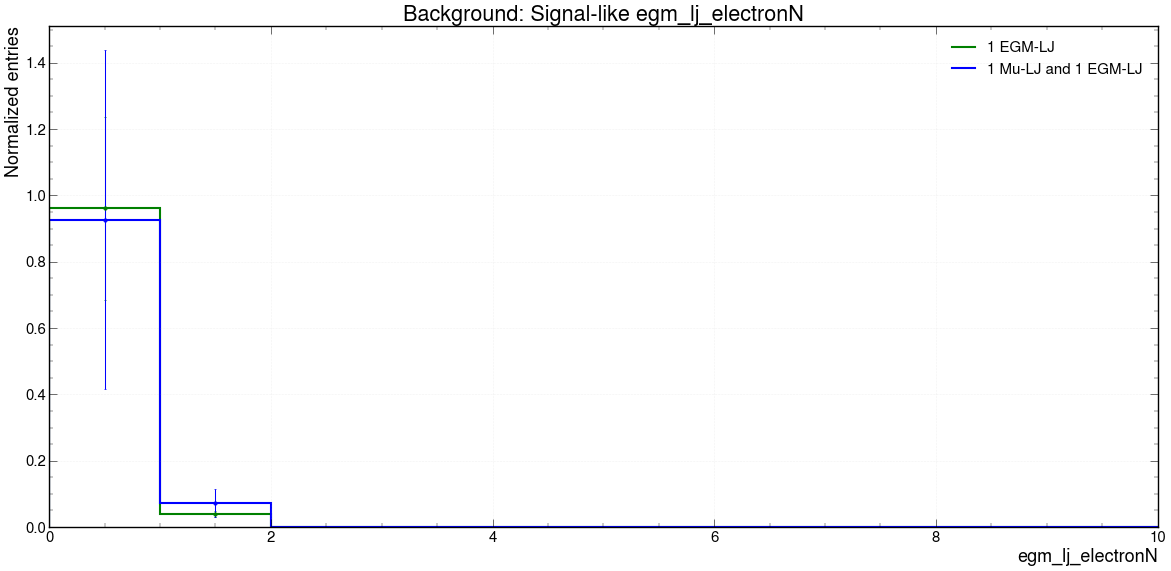

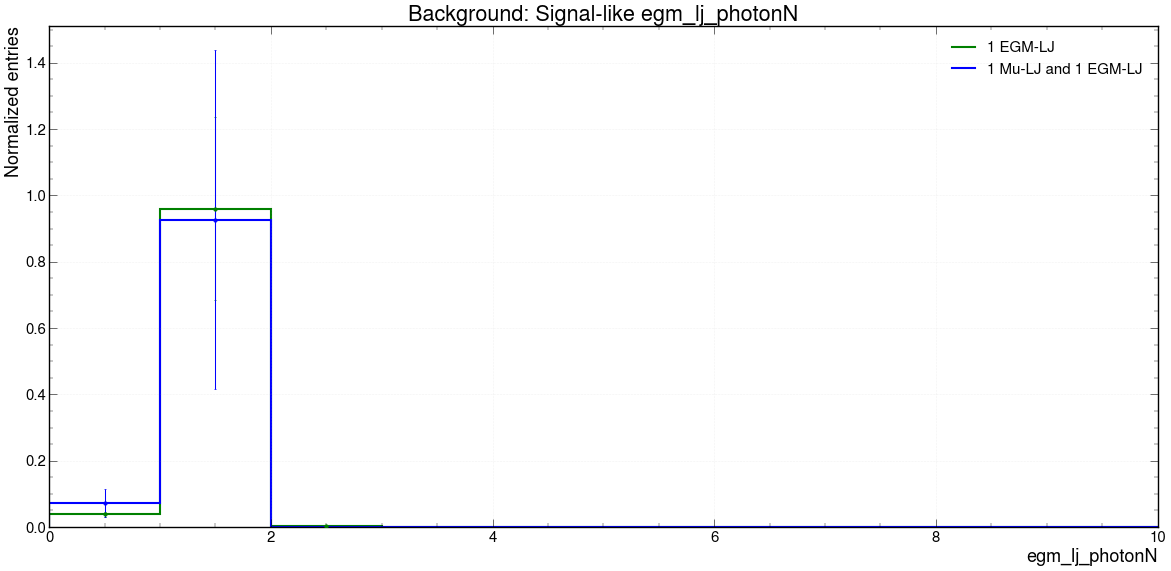

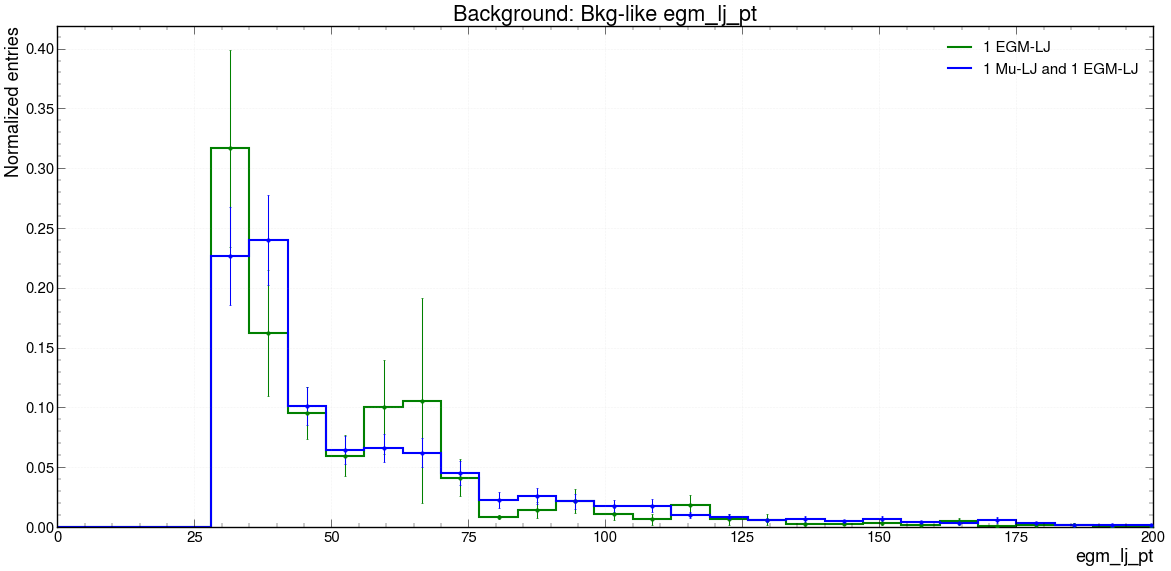

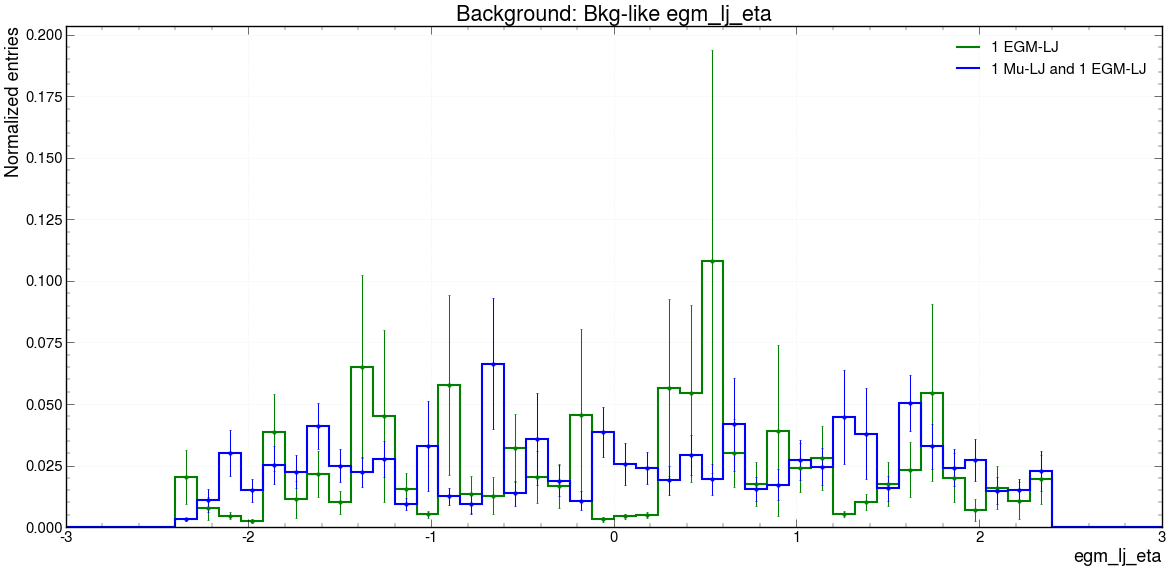

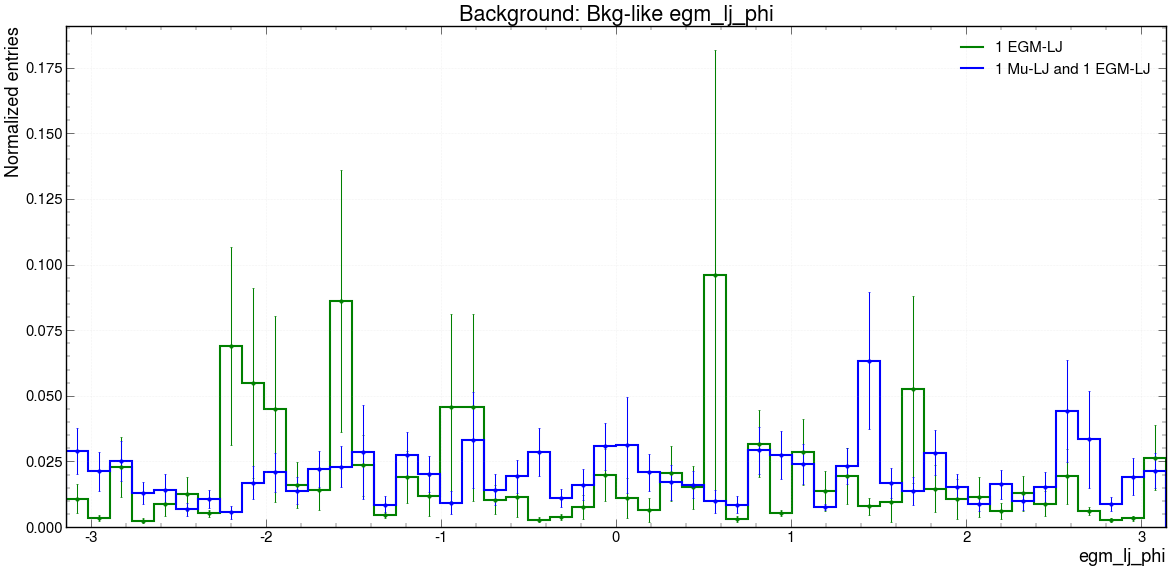

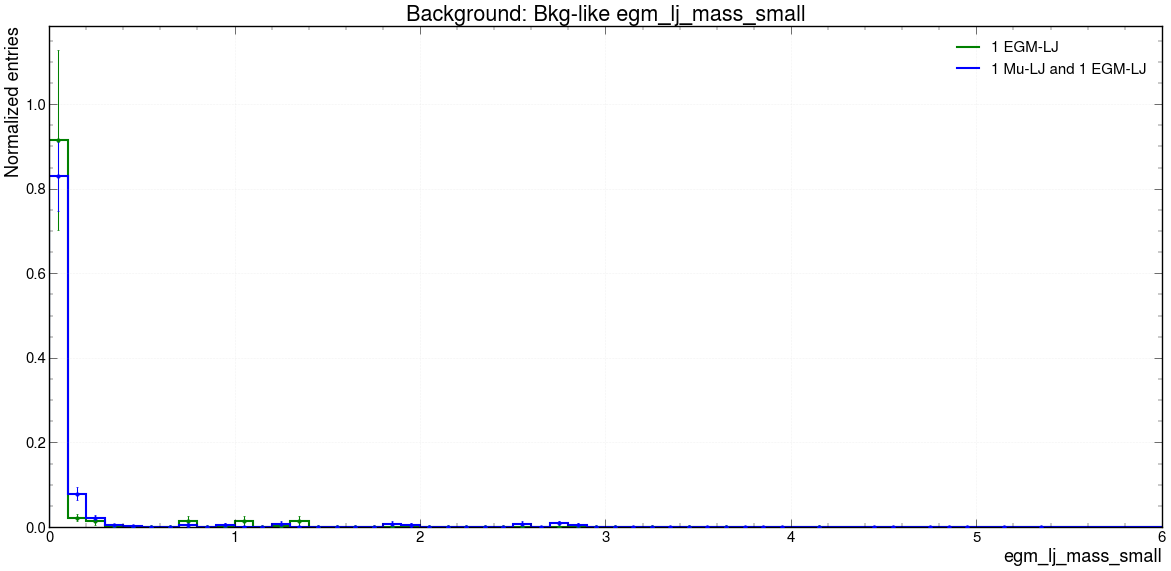

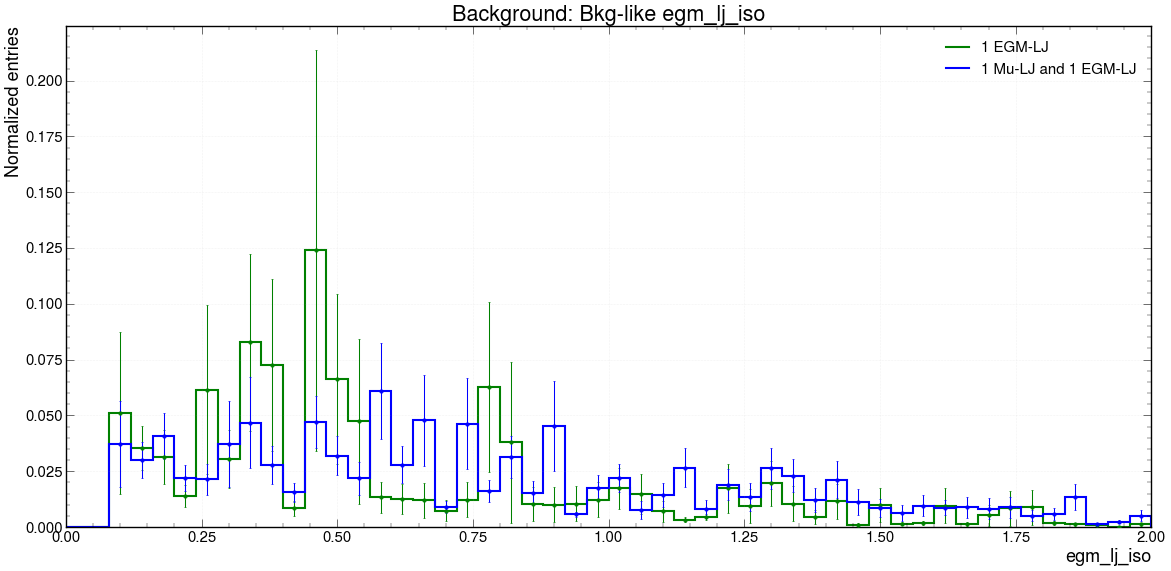

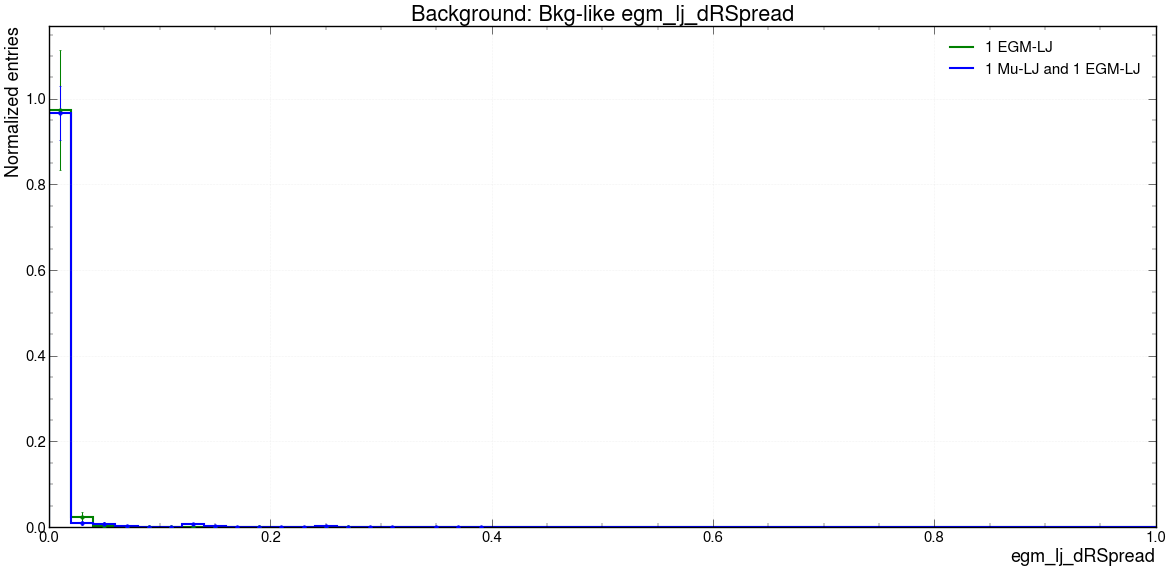

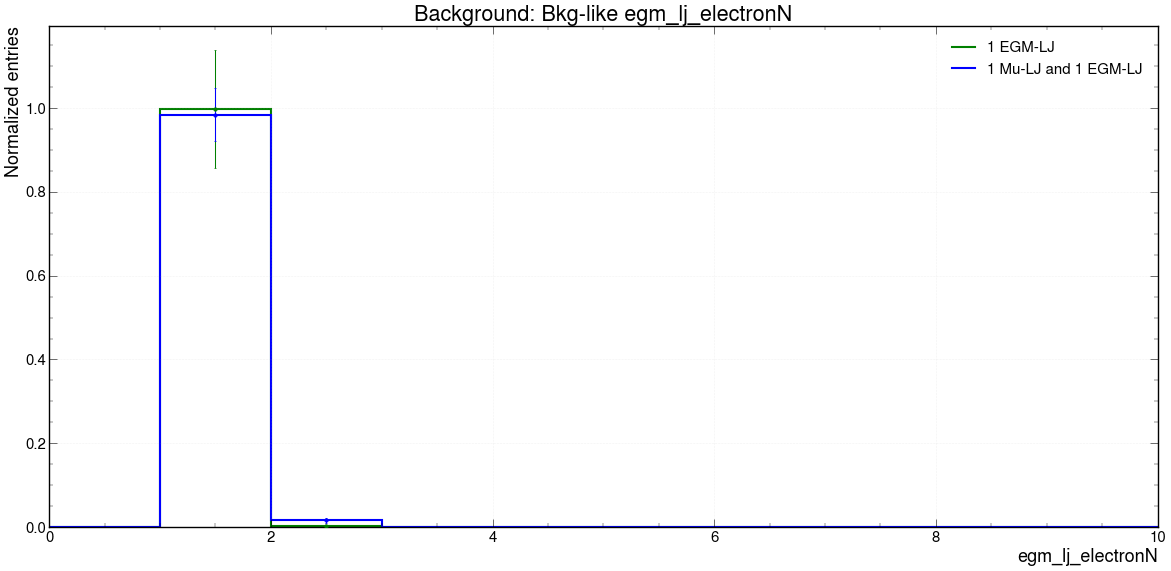

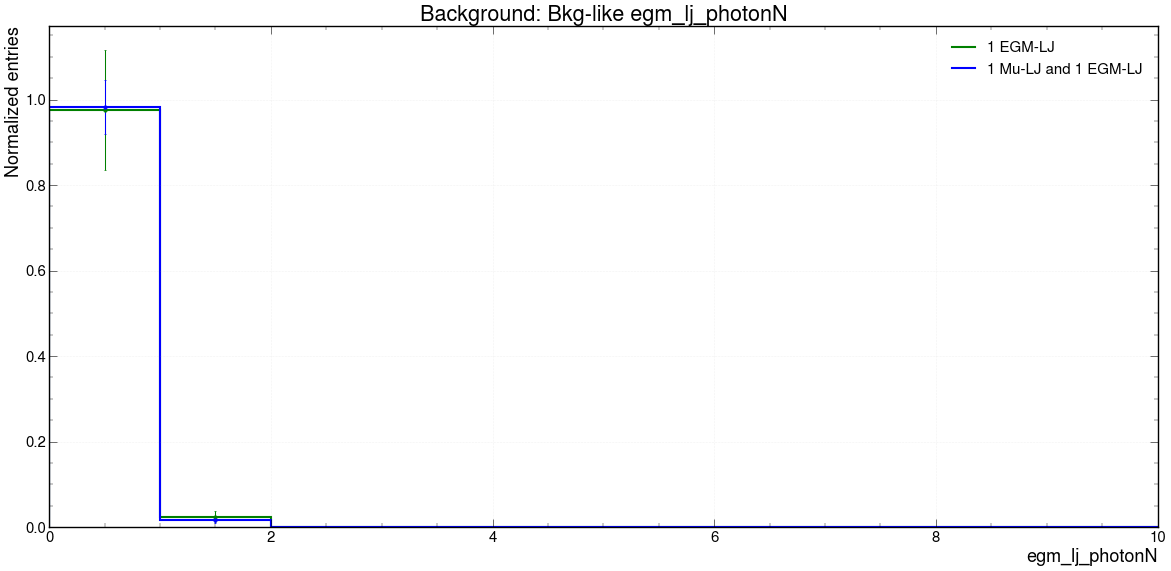

In [33]:
for region in ['both_pass', 'both_fail']:
    for variable in egm_lj_variables:
        plot_shape_for_region(
            egm_channels,
            background_samples,
            variable,
            region=region,
            title=f'{background_label}: {REGION_LABELS[region]} {variable}',
            show_errors=True,
            **PLOT_OPTIONS.get(variable, {}),
        )


In [5]:
overall_mother_table = mother_composition_table(mother_out, background_samples)
display(overall_mother_table.round(2))

,W,Z,D,B,quark/gluon,pion,eta/omega,J/psi,electron,muon,other
1 Mu-LJ,0.03,0.64,25.55,24.46,14.17,15.63,2.03,8.54,0.00,0.05,8.90
1 EGM-LJ,3.19,0.01,5.90,17.47,9.21,53.24,2.71,0.06,1.43,0.05,6.72
1 Mu-LJ and 1 EGM-LJ,0.57,0.57,22.44,24.12,6.68,28.98,2.80,5.65,0.20,0.07,7.92
2 Mu-LJ,0.10,0.17,31.27,29.58,3.19,20.78,1.60,4.92,0.00,0.08,8.30


,W,Z,D,B,quark/gluon,pion,eta/omega,J/psi,electron,muon,other
1 Mu-LJ,0.03,0.64,25.55,24.46,14.17,15.63,2.03,8.54,0.00,0.05,8.90
1 EGM-LJ,3.19,0.01,5.90,17.47,9.21,53.24,2.71,0.06,1.43,0.05,6.72
1 Mu-LJ and 1 EGM-LJ,0.57,0.57,22.44,24.12,6.68,28.98,2.80,5.65,0.20,0.07,7.92
2 Mu-LJ,0.10,0.17,31.27,29.58,3.19,20.78,1.60,4.92,0.00,0.08,8.30


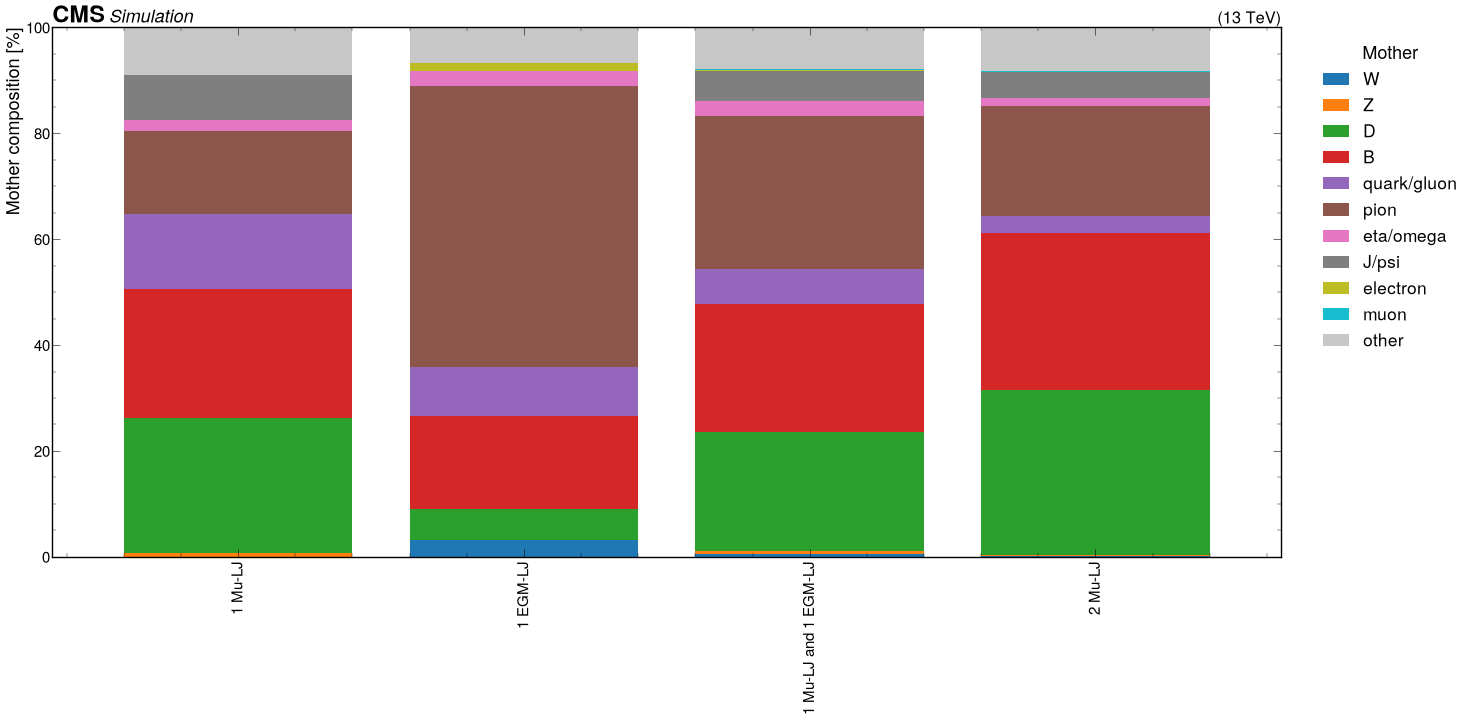

In [7]:
import mplhep as hep

overall_mother_table = mother_composition_table(mother_out, background_samples)
display(overall_mother_table.round(2))

simulation_mother_ax = plot_mother_composition(
    overall_mother_table,
    None,
)
hep.cms.label(data=False, ax=simulation_mother_ax)
plt.tight_layout()